In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
from sklearn.datasets import load_diabetes
from statsmodels.tsa.seasonal import seasonal_decompose

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'AppleGothic'
# plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ch9_Visualization(1)
<h5>변수 분포 보기 : 히스토그램(Histogram), 박스플롯(Box Plot), 산점도(Scatter Plot)
<h5>변수 간 관계 보기 : 산점도(Scatter Plot), 상관 히트맵(Heatmap)
<h5>범주형 데이터 보기 : 카운트 플롯(Count Plot)
<h5>시간 흐름 보기 : 라인 플롯(Line Plot)

<b>그래프에서 기본적으로 표현해야할 것</b>
1. 데이터 : 숫자나 범주형 값
2. 축 : 어떤 기준에서 비교하는지
3. 타이틀 : 무엇을 보여주는지
4. 범례 : 어떤 데이터인지 구분
5. 스타일 : 색상, 격자, 마커 등 시각적 표현

In [91]:
import matplotlib.pyplot as plt 

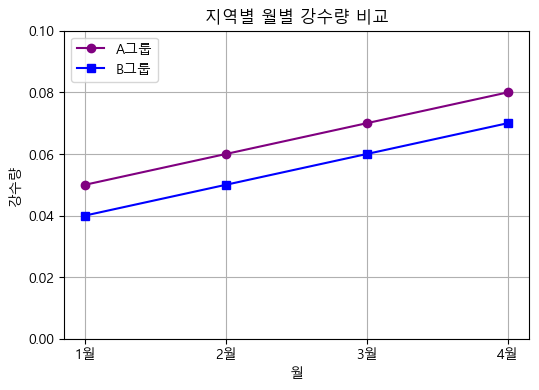

In [92]:
months = ['1월', '2월', '3월', '4월']
A = [0.05, 0.06, 0.07, 0.08]
B = [0.04, 0.05, 0.06, 0.07]

plt.figure(figsize=(6,4))
plt.plot(months, A, marker='o', color='purple', label='A그룹') # marker이 동그라미
plt.plot(months, B, marker='s', color='blue', label='B그룹') # marker이 정사각형
plt.title('지역별 월별 강수량 비교')
plt.xlabel('월')
plt.ylabel('강수량')
plt.ylim(0, 0.1) # y축 범위 지정
plt.grid(True) # 격자 표시 여부
plt.legend(loc='upper left') # 범례 위치 지정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.show()

<h2>Line Plot 선 차트

In [93]:
import seaborn as sns

In [94]:
iris = sns.load_dataset('iris')
iris = iris.drop(labels='species', axis=1)
iris

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


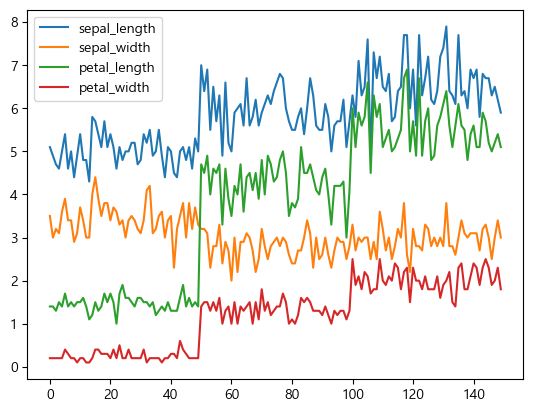

In [95]:
iris.plot()
plt.show()

<Axes: >

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


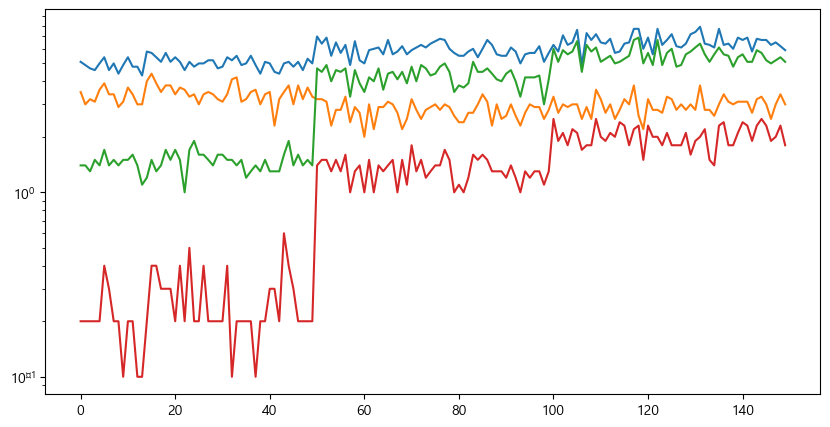

In [96]:
iris.plot(legend=False, figsize=(10, 5), logy=True)
# logy : y축 값을 log scale로 나타냄 (logx = True : x축 값을 log scale로 나타냄)

In [97]:
iris1 = iris[['sepal_width', 'petal_width']]
iris2 = iris[['sepal_length', 'petal_length']]
print(iris1.head())
print(iris2.head())

   sepal_width  petal_width
0          3.5          0.2
1          3.0          0.2
2          3.2          0.2
3          3.1          0.2
4          3.6          0.2
   sepal_length  petal_length
0           5.1           1.4
1           4.9           1.4
2           4.7           1.3
3           4.6           1.5
4           5.0           1.4


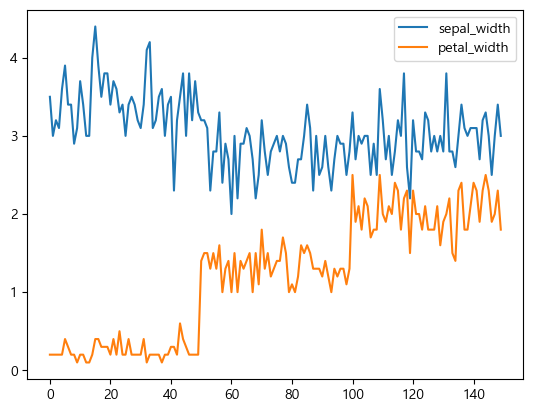

In [98]:
ax1 = iris1.plot()

<Axes: >

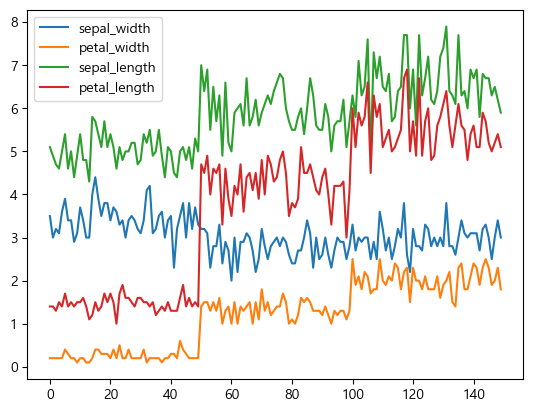

In [99]:
ax1 = iris1.plot()
iris2.plot(ax = ax1)

<Axes: >

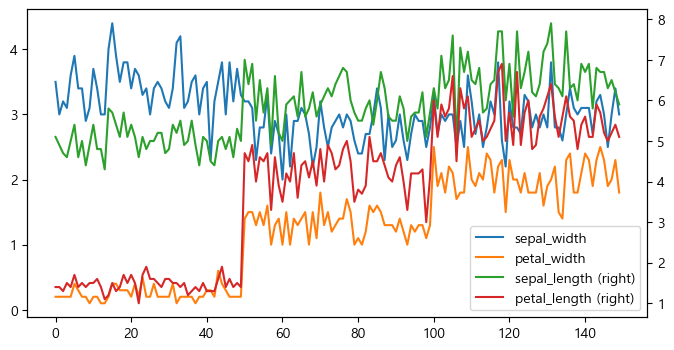

In [100]:
ax1 = iris1.plot()
iris2.plot(figsize=(8,4), ax = ax1, secondary_y=True)

In [ ]:
# yfinance 라이브러리를 사용하여 2020년 1월 1일부터 2025년 4월 30일까지의 S&P500(^GSPC) 지수의
# 데이터를 다운로드하여 데이터프레임으로 만들고,

import yfinance as yf

ticker = '^GSPC'

gspc_data = yf.download(ticker, start="2020-01-01", end="2025-04-30")

In [ ]:
# OHLC(Open, High, Low, Close) 가격 데이터를 선 그래프로 시각화하되, ax1객체로 출력하시오.

ohlc = gspc_data[['Open', 'High', 'Low', 'Close']]

ax1 = ohlc.plot(figsize=(12,6))

In [ ]:
# Volume 데이터를 선 그래프로 시각회하되, ax2 객체로 출력하시오.

volume = gspc_data[['Volume']]

ax2 = volume.plot()

In [ ]:
# 두 그래프를 하나의 차트로 겹쳐 그리되, y축을 분리하시오.

ax1 = ohlc.plot(figsize=(12,6))
volume.plot(ax = ax1, color = 'gray', alpha = 0.5, secondary_y = True)

In [ ]:
# 위의 동일한 데이터프레임에서 OHLC의 로그 수익률 그래프를 그려보시오. (log(return) = log(P(t) / P(t-1)))

import numpy as np
import matplotlib.pyplot as plt

# 로그 수익률 계산
log_return = np.log(ohlc['Close'] / ohlc['Close'].shift(1))

# NaN 제거
log_return = log_return.dropna()

# 그래프 그리기
plt.figure(figsize=(12,6))
plt.plot(log_return, label='Log Return (Close)', color='purple')
plt.title('S&P 500 종가 로그 수익률')
plt.xlabel('날짜')
plt.ylabel('로그 수익률')
plt.grid(True)
plt.legend()
plt.show()

<h2>Bar Plot 막대 차트

<Axes: >

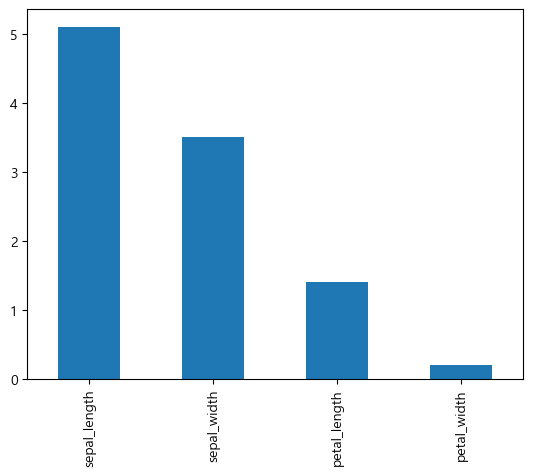

In [101]:
iris = sns.load_dataset('iris')
iris = iris.drop(['species'], axis = 1)
iris.iloc[0].plot(kind='bar')
# df.iloc[0].plot.bar()

<Axes: >

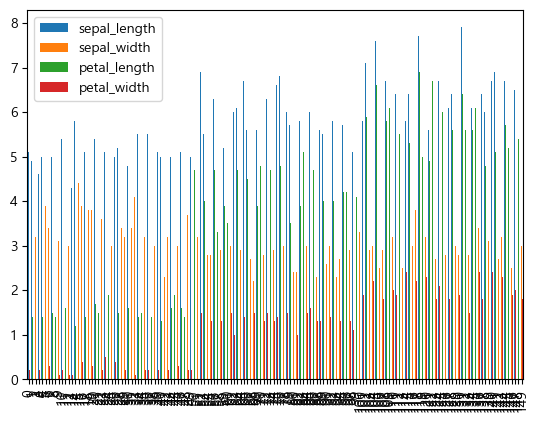

In [102]:
iris.plot.bar()

In [103]:
iris_mean = iris.mean()
iris_mean

sepal_length    5.843333
sepal_width     3.057333
petal_length    3.758000
petal_width     1.199333
dtype: float64

C:\Users\D401-24\AppData\Local\Temp\ipykernel_14732\2562071024.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=iris_mean, palette='Set2')


<Axes: >

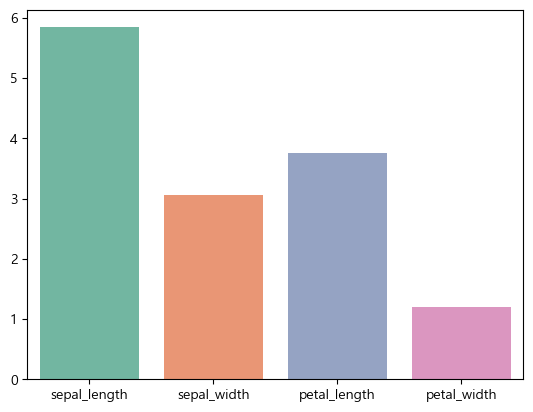

In [104]:
sns.barplot(data=iris_mean, palette='Set2')

<h2>연습문제

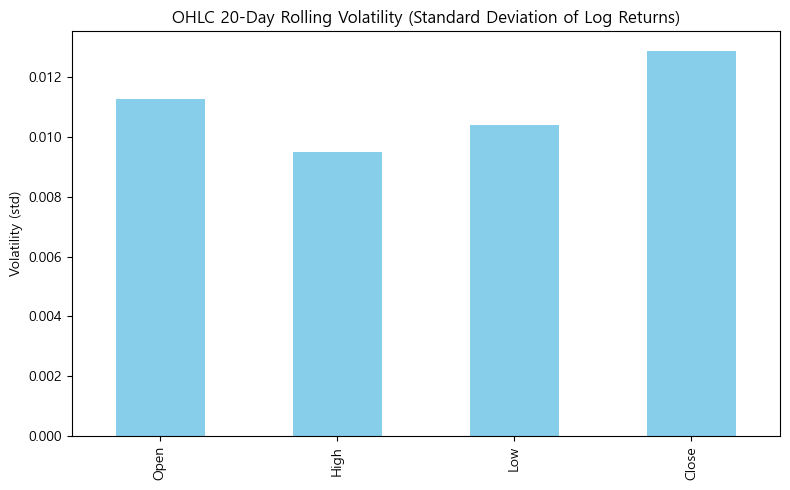

In [105]:
# 데이터 다운로드
df = pd.read_csv('gspc_data.csv')

# 2. 로그수익률 계산 (OHLC 각각)
log_returns = np.log(df[['Open', 'High', 'Low', 'Close']] / df[['Open', 'High', 'Low', 'Close']].shift(1))

# 3. 일간 변동성 (20일 rolling 표준편차)
vol_20d = log_returns.rolling(window=20).std()

import matplotlib.pyplot as plt
# 4. OHLC 일간 변동성 비교: 가장 마지막 날짜 기준 막대그래프
plt.figure(figsize=(8, 5))
vol_20d.iloc[-1].plot(kind='bar', color='skyblue')
plt.title("OHLC 20-Day Rolling Volatility (Standard Deviation of Log Returns)")
plt.ylabel("Volatility (std)")
plt.tight_layout()
plt.show()

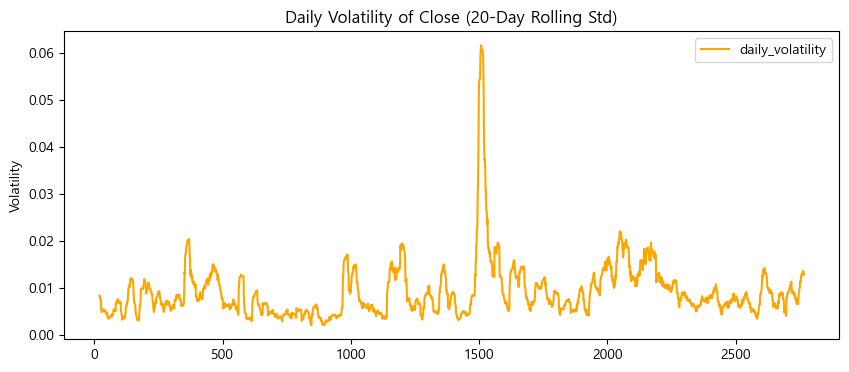

In [106]:
# 5. Close 기준: 일간 변동성 시계열 그래프
df['log_return_close'] = np.log(df['Close'] / df['Close'].shift(1))
df['daily_volatility'] = df['log_return_close'].rolling(window=20).std()

plt.figure(figsize=(10, 4))
df['daily_volatility'].plot(color='orange')
plt.title("Daily Volatility of Close (20-Day Rolling Std)")
plt.ylabel("Volatility")
plt.legend(loc='upper right') 
plt.show()

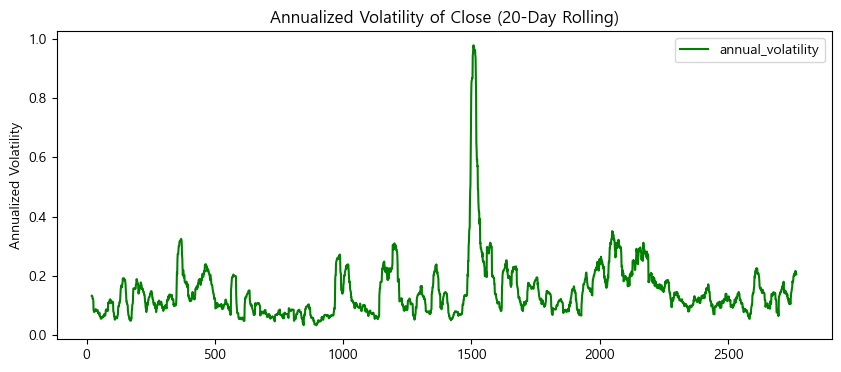

In [107]:
# 6. Close 기준: 연간 변동성 시계열 그래프 (× √252)
df['annual_volatility'] = df['daily_volatility'] * np.sqrt(252)

plt.figure(figsize=(10, 4))
df['annual_volatility'].plot(color='green')
plt.title("Annualized Volatility of Close (20-Day Rolling)")
plt.ylabel("Annualized Volatility")
plt.legend(loc='upper right') 
plt.show()

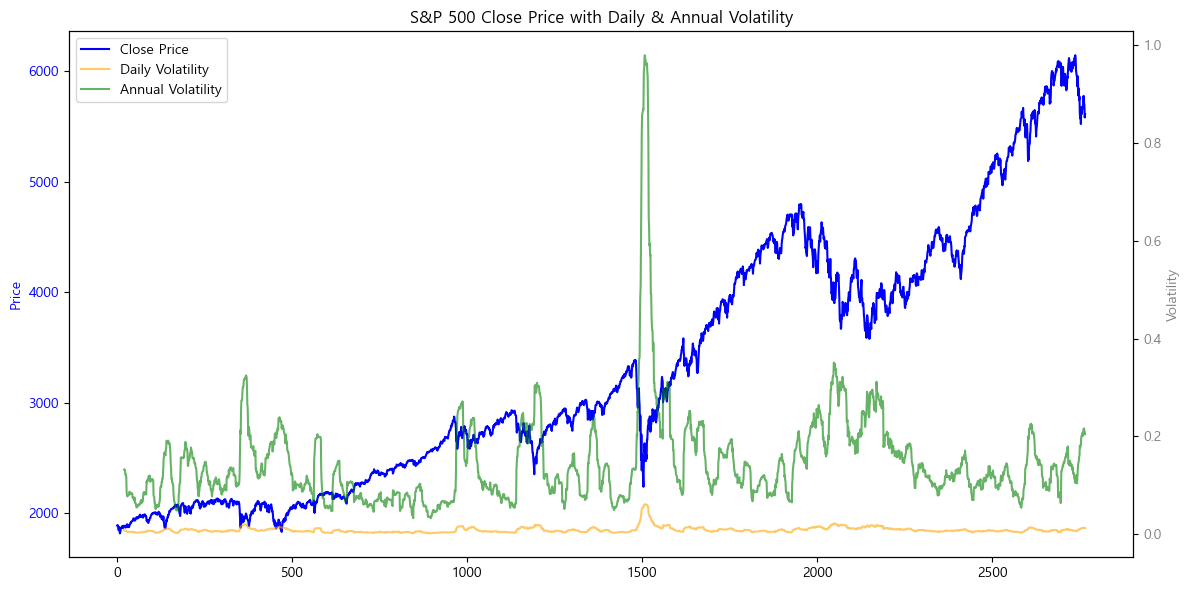

In [108]:
# 7. Close 가격, 일간 변동성, 연간 변동성을 한 차트에
fig, ax1 = plt.subplots(figsize=(12, 6))

# Close 가격 (왼쪽 축)
ax1.plot(df.index, df['Close'], color='blue', label='Close Price')
ax1.set_ylabel('Price', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# 변동성 (오른쪽 축)
ax2 = ax1.twinx()
ax2.plot(df.index, df['daily_volatility'], color='orange', label='Daily Volatility', alpha=0.6)
ax2.plot(df.index, df['annual_volatility'], color='green', label='Annual Volatility', alpha=0.6)
ax2.set_ylabel('Volatility', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

# 범례 병합
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title("S&P 500 Close Price with Daily & Annual Volatility")
plt.tight_layout()
plt.show()

In [ ]:
'''
Annual Volatility (연두색 선)
일간 변동성을 √252만큼 스케일 업한 값이므로, 전체적인 패턴은 유사하지만 수치적으로 더 큼
일정 구간 동안의 변동성을 누적 반영하기 때문에, 급변 이후에도 서서히 줄어드는 모양이 자주 나타남.
고점에서의 꼬리 효과: 충격 이후에도 변동성이 한동안 높게 유지된다는 점을 보여줌.
'''

<h2>Stacked Bar Plot 누적 막대 차트

In [110]:
df = pd.DataFrame(np.random.randn(10,4), columns=['a', 'b', 'c', 'd'])
df

,a,b,c,d
0,-1.188859,-0.506816,-0.596314,-0.052567
1,-1.936280,0.188779,0.523891,0.088422
2,-0.310886,0.097400,0.399046,-2.772593
3,1.955912,0.390093,-0.652409,-0.390953
4,0.493742,-0.116104,-2.030684,2.064493
5,-0.110541,1.020173,-0.692050,1.536377
6,0.286344,0.608844,-1.045253,1.211145
7,0.689818,1.301846,-0.628088,-0.481027
8,2.303917,-1.060016,-0.135950,1.136891
9,0.097725,0.582954,-0.399449,0.370056


<Axes: >

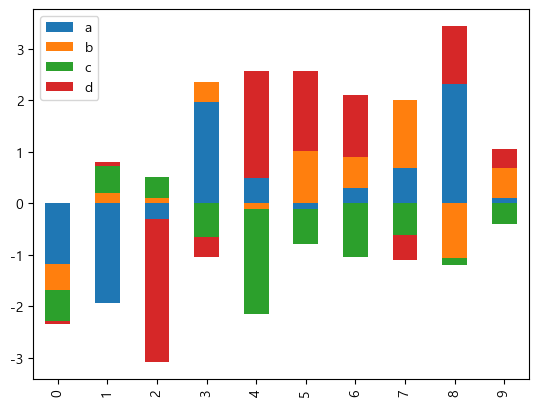

In [111]:
df.plot.bar(stacked=True)
# stacked=True : 누적막대차트

<Axes: >

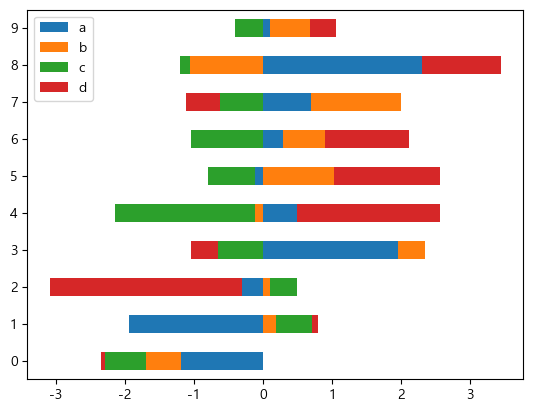

In [112]:
df.plot.barh(stacked = True)

<h2>Histogram 히스토그램

<Axes: ylabel='Frequency'>

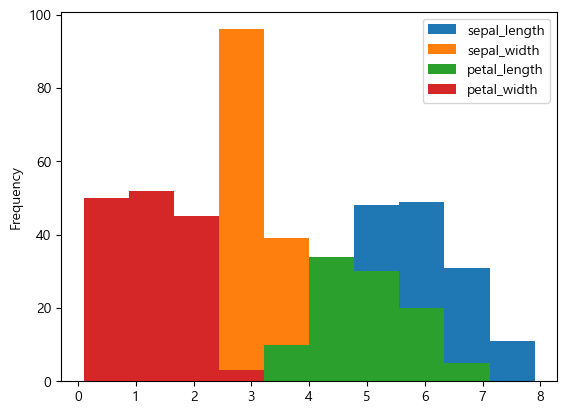

In [113]:
iris.plot.hist()
# iris.plot(kind='hist')

<Axes: ylabel='Frequency'>

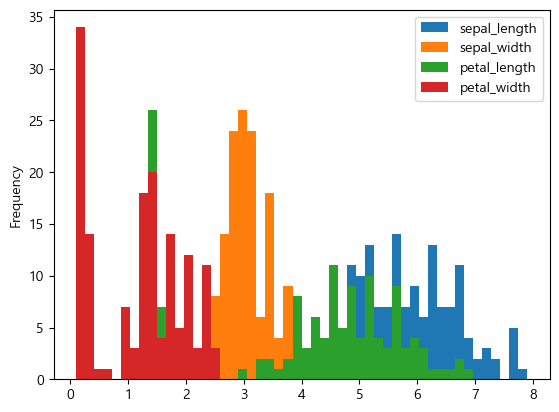

In [114]:
iris.plot(kind='hist', bins=50)

<Axes: xlabel='Frequency'>

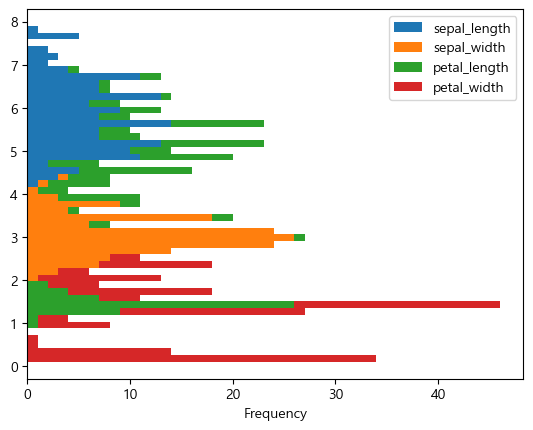

In [115]:
iris.plot(kind='hist', bins=50, stacked=True, orientation='horizontal')
# stacked=True : 각 bin에 대응되는 각 특징의 도수가 더해진 값이 히스토그램으로 나타남
# orientation = 'horizontal' : 가로축과 세로축이 바뀌어진 형태로 그려짐

<Axes: ylabel='Frequency'>

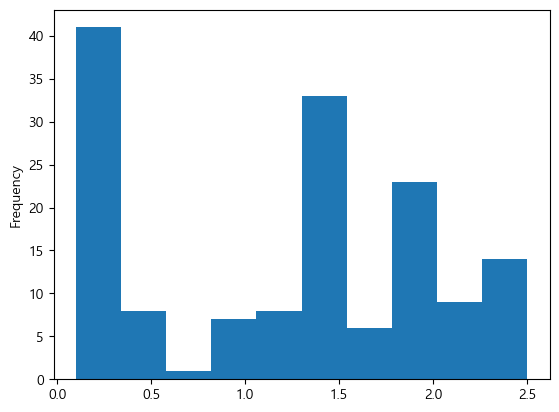

In [116]:
iris['petal_width'].plot(kind='hist')

array([[<Axes: title={'center': 'sepal_length'}>,
        <Axes: title={'center': 'sepal_width'}>],
       [<Axes: title={'center': 'petal_length'}>,
        <Axes: title={'center': 'petal_width'}>]], dtype=object)

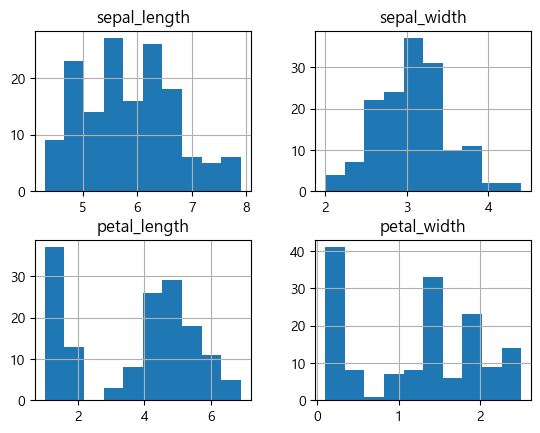

In [117]:
iris.hist()

array([[<Axes: title={'center': 'sepal_length'}>,
        <Axes: title={'center': 'sepal_width'}>],
       [<Axes: title={'center': 'petal_length'}>,
        <Axes: title={'center': 'petal_width'}>]], dtype=object)

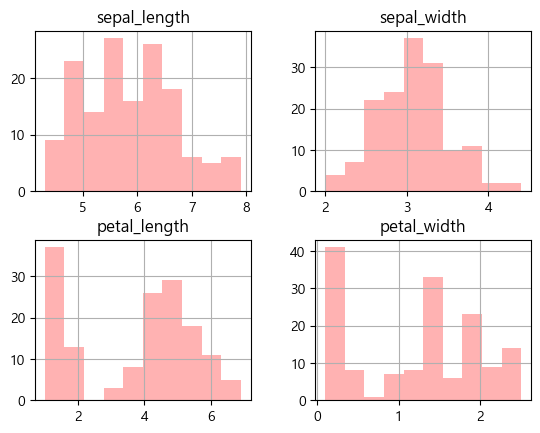

In [118]:
iris.hist(color='r', alpha=0.3) # alpha : 투명도

array([[<Axes: title={'center': 'sepal_length'}>,
        <Axes: title={'center': 'sepal_width'}>],
       [<Axes: title={'center': 'petal_length'}>,
        <Axes: title={'center': 'petal_width'}>]], dtype=object)

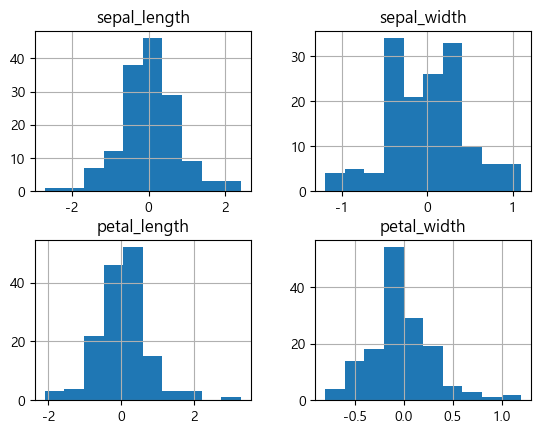

In [119]:
iris.diff().hist()
# dataframe.diff()는 요소와 요소간의 차이(기본값은 아래 행 데이터와의 차)로 새로운 df 만들어 반환

<h2>Scatter Plot 분산형 차트

<Axes: xlabel='sepal_width', ylabel='petal_width'>

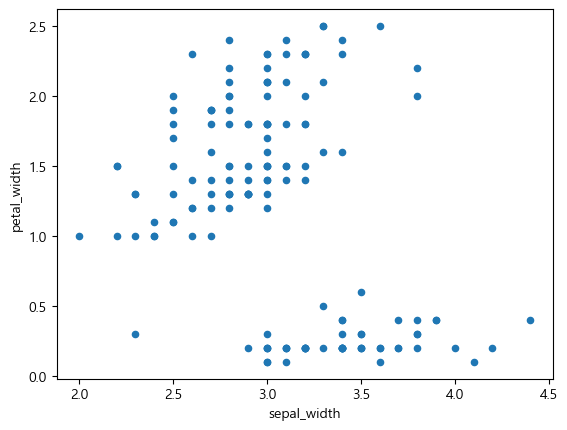

In [120]:
iris.plot.scatter(x='sepal_width', y='petal_width')

<Axes: xlabel='sepal_width', ylabel='petal_width'>

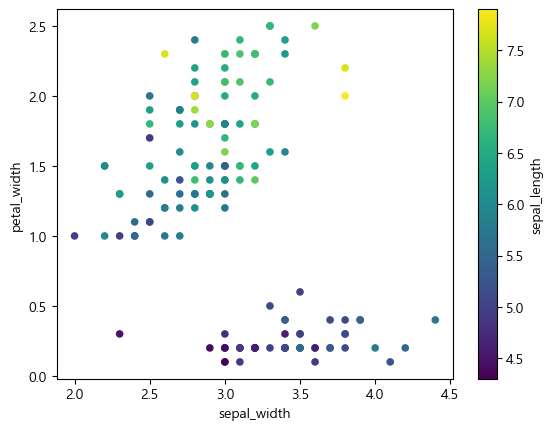

In [121]:
iris.plot.scatter(x='sepal_width', y='petal_width', c='sepal_length')

<Axes: xlabel='sepal_length', ylabel='petal_length'>

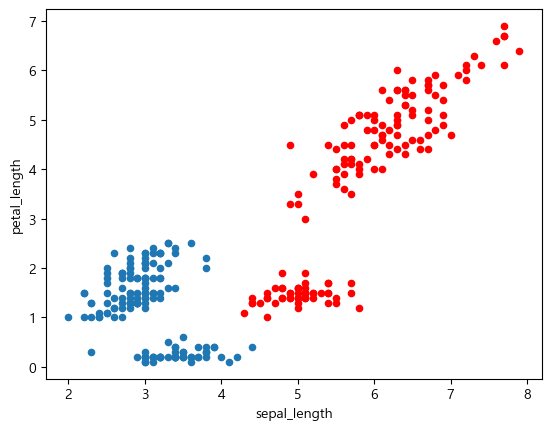

In [122]:
ax = iris.plot.scatter(x = 'sepal_width', y = 'petal_width')
iris.plot.scatter(x = 'sepal_length', y = 'petal_length', ax = ax, color = 'r')

<h2>Scatter Marix 산점도 행렬

In [123]:
from pandas.plotting import scatter_matrix

array([[<Axes: xlabel='sepal_length', ylabel='sepal_length'>,
        <Axes: xlabel='sepal_width', ylabel='sepal_length'>,
        <Axes: xlabel='petal_length', ylabel='sepal_length'>,
        <Axes: xlabel='petal_width', ylabel='sepal_length'>],
       [<Axes: xlabel='sepal_length', ylabel='sepal_width'>,
        <Axes: xlabel='sepal_width', ylabel='sepal_width'>,
        <Axes: xlabel='petal_length', ylabel='sepal_width'>,
        <Axes: xlabel='petal_width', ylabel='sepal_width'>],
       [<Axes: xlabel='sepal_length', ylabel='petal_length'>,
        <Axes: xlabel='sepal_width', ylabel='petal_length'>,
        <Axes: xlabel='petal_length', ylabel='petal_length'>,
        <Axes: xlabel='petal_width', ylabel='petal_length'>],
       [<Axes: xlabel='sepal_length', ylabel='petal_width'>,
        <Axes: xlabel='sepal_width', ylabel='petal_width'>,
        <Axes: xlabel='petal_length', ylabel='petal_width'>,
        <Axes: xlabel='petal_width', ylabel='petal_width'>]], dtype=object)

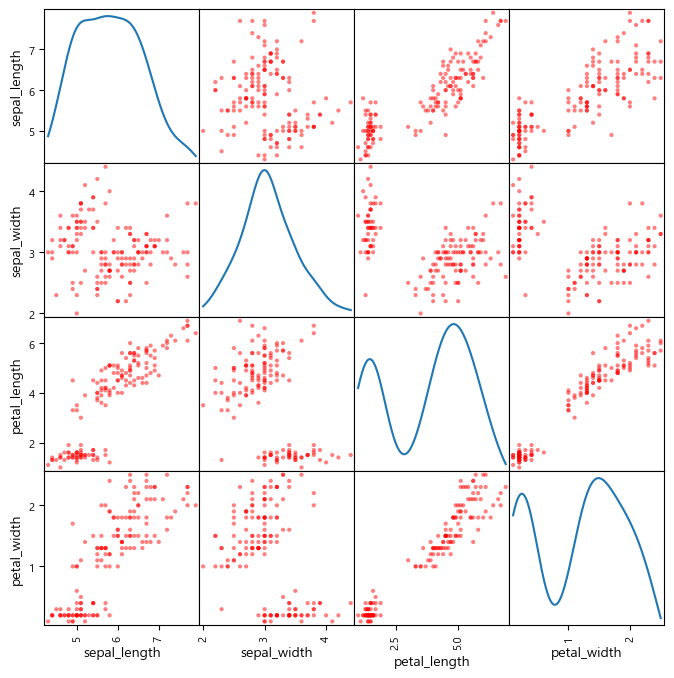

In [124]:
scatter_matrix(iris, figsize=(8,8), diagonal='kde', color='r')
# kde (커널 밀도 추정) : 히스토그램을 기반으로 커널 함수를 사용하여 밀도를 추정 (히스토그램을 매끄럽게 한 형태)
# diagonal = 'hist' or 'kde'

<h2>Subplots 서브플롯

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

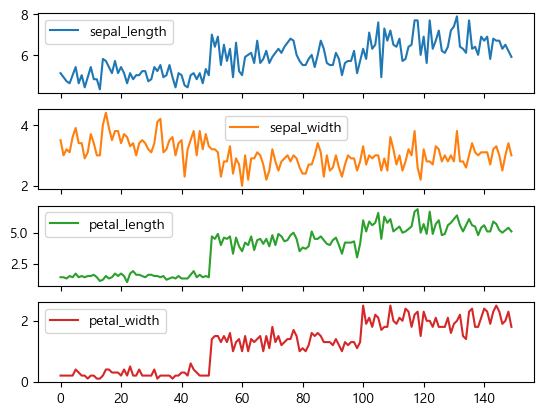

In [125]:
iris.plot(subplots=True)
# subplots=True : 모든 열이 분리되어 서로 다른 차트에 선차트가 개별 생성

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

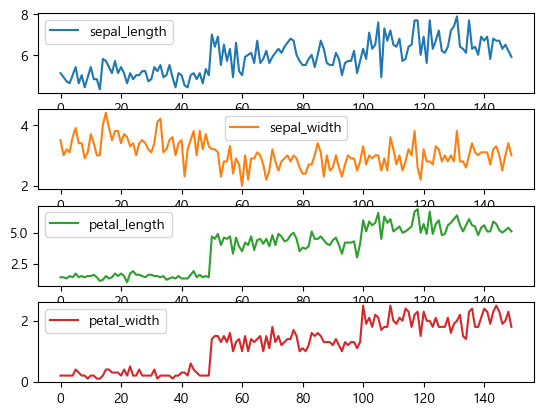

In [126]:
iris.plot(subplots=True, sharex=False)
# sharex=False : x축 눈금값을 차트별로 개별 표기

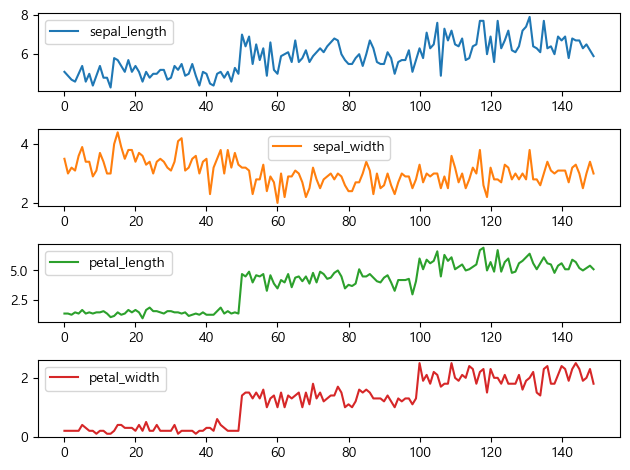

In [127]:
iris.plot(subplots=True, sharex=False,)
plt.tight_layout()
# plt.tight_layout() : 차트와 텍스트 간의 오버랩 방지

array([[<Axes: >, <Axes: >],
       [<Axes: >, <Axes: >]], dtype=object)

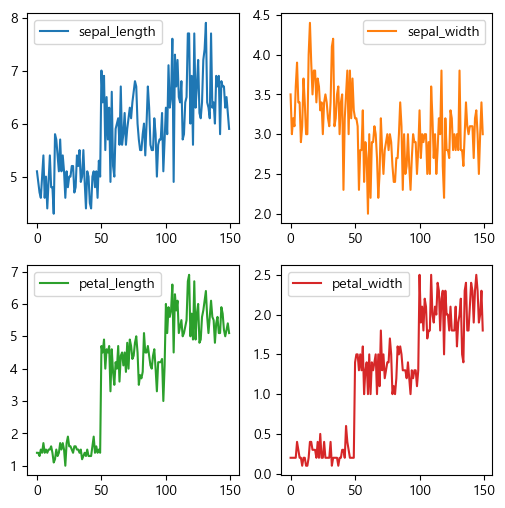

In [128]:
iris.plot(subplots=True, sharex=False, layout=(2,2), figsize=(6,6))
# layout : subplot의 차트의 배열을 결정 ((2,2)는 2행 2열)

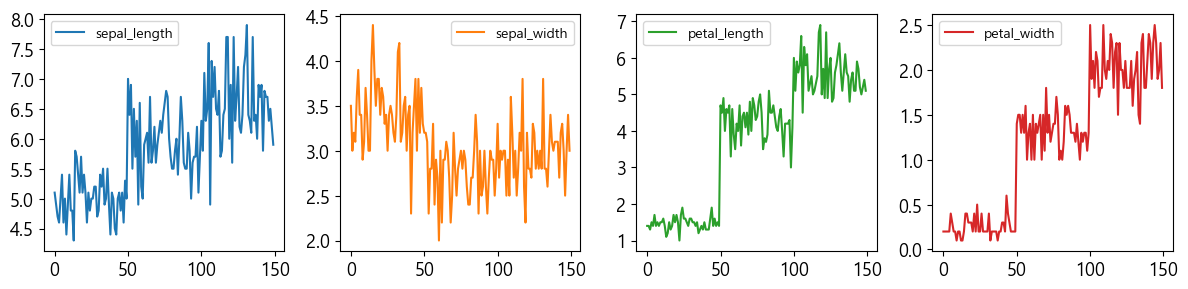

In [129]:
iris.plot(subplots=True, sharex=False, layout=(1,4), figsize=(12,3), fontsize=13)
plt.tight_layout()

<h2>연습문제

In [130]:
# 1. 연도별 승객 수의 추이를 선 그래프로 나타내시오, month를 기준으로 여러 선을 그려 월별 추이를 비교하시오
flights = sns.load_dataset('flights')
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


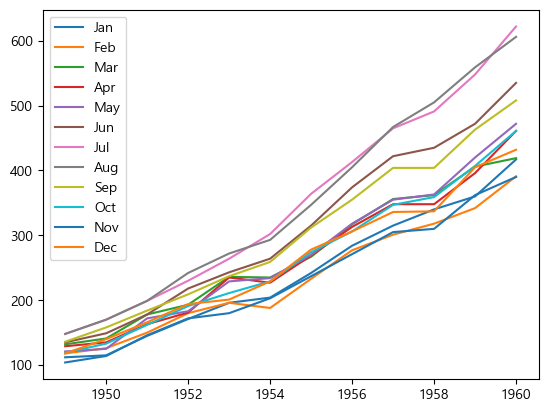

In [131]:
for month in flights['month'].unique() :
    sub = flights[flights['month'] == month]
    plt.plot(sub['year'], sub['passengers'], label = month)
plt.legend()
plt.show()

In [132]:
# 2. age, bp, s1, s5 변수와 bmi간의 관계를 시각화하시오.
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()
diabetes

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]]),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142., 155., 225.,  59

In [133]:
diabetes['feature_names']

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

In [134]:
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

In [135]:
df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930


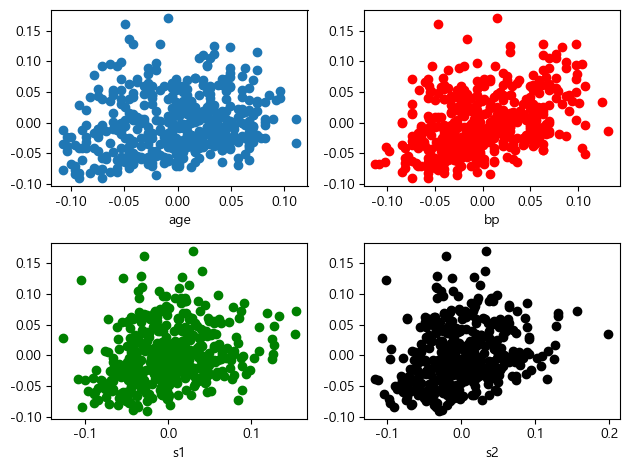

In [136]:
fig, axes = plt.subplots(2, 2)

axes[0, 0].scatter(df['age'], df['bmi'])
axes[0, 0].set_xlabel('age')

axes[0, 1].scatter(df['bp'], df['bmi'], color='red')
axes[0, 1].set_xlabel('bp')

axes[1, 0].scatter(df['s1'], df['bmi'], color='green')
axes[1, 0].set_xlabel('s1')

axes[1, 1].scatter(df['s2'], df['bmi'], color='black')
axes[1, 1].set_xlabel('s2')

plt.tight_layout()

In [137]:
# 3. 성별별 생존률을 막대그래프로 나타내시오, class와 sex를 기준으로 그룹화하여 생존률 차이를 비교해보세요.
titanic = sns.load_dataset('titanic')
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [138]:
surv_s = titanic.groupby('sex')['survived'].mean()
surv_s

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

In [139]:
surv_cs = titanic.groupby(['class', 'sex'])['survived'].mean().reset_index()
# reset_index() 는 깔끔한 시각화를 위해 씀
surv_cs

C:\Users\D401-24\AppData\Local\Temp\ipykernel_14732\4004663725.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  surv_cs = titanic.groupby(['class', 'sex'])['survived'].mean().reset_index()


,class,sex,survived
0,First,female,0.968085
1,First,male,0.368852
2,Second,female,0.921053
3,Second,male,0.157407
4,Third,female,0.500000
5,Third,male,0.135447


<Axes: >

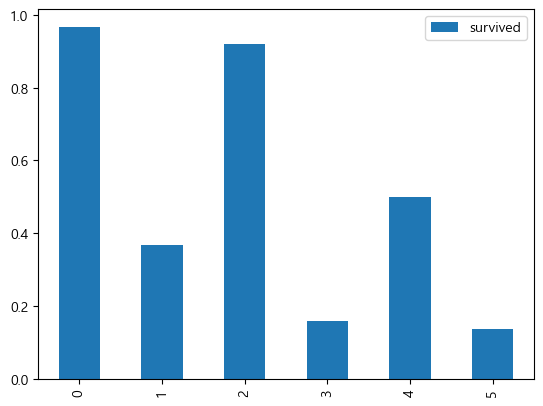

In [140]:
surv_cs.plot(kind='bar')

C:\Users\D401-24\AppData\Local\Temp\ipykernel_14732\3571105915.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=surv_by_sex,


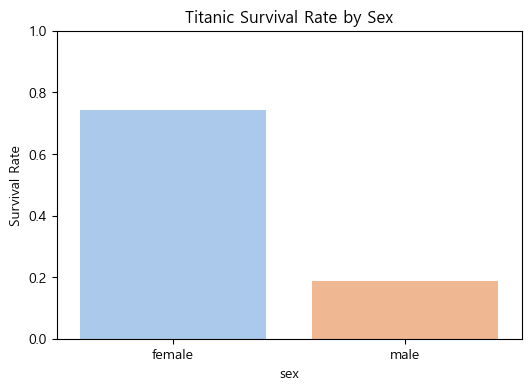

C:\Users\D401-24\AppData\Local\Temp\ipykernel_14732\3571105915.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['class', 'sex'])['survived']


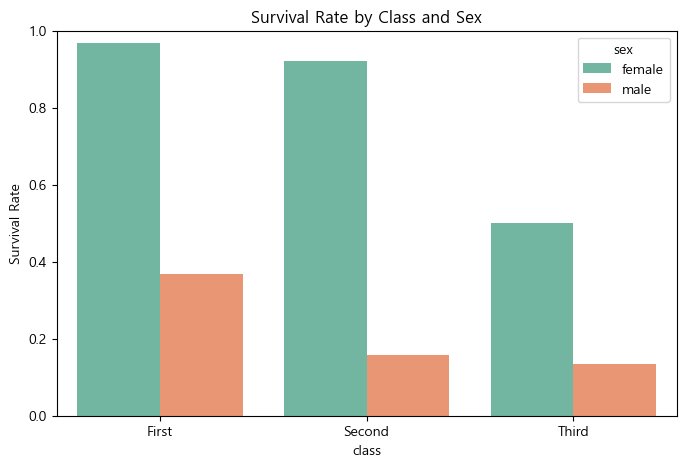

In [141]:
# ─────────────────────────────────────────────
# 2) 성별별 평균 생존율
surv_by_sex = titanic.groupby('sex')['survived'].mean().reset_index()

plt.figure(figsize=(6, 4))
sns.barplot(data=surv_by_sex,
            x='sex', y='survived',
            palette='pastel')
plt.title('Titanic Survival Rate by Sex')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.show()

# ─────────────────────────────────────────────
# 3) class × sex 교차그룹 평균 생존율
surv_cls_sex = (titanic
                .groupby(['class', 'sex'])['survived']
                .mean()
                .reset_index())

plt.figure(figsize=(8, 5))
sns.barplot(data=surv_cls_sex,
            x='class', y='survived',
            hue='sex',
            palette='Set2')
plt.title('Survival Rate by Class and Sex')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.show()

In [142]:
# 4. price의 분포를 median 기준으로 고가/저가로 구분하여 각각 히스토그램을 그려본 후 분포 차이를 해석하시오.
# carat의 히스토그램도 고가/저가로 비교하여 시각화하시오.
diamonds = sns.load_dataset('diamonds')
diamonds

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [143]:
dia_median = diamonds['price'].median()

price_level = []
for p in diamonds['price'] :
    if p > dia_median :
        price_level.append('high')
    else :
        price_level.append('low')
        
diamonds['price_level'] = price_level
diamonds

,carat,cut,color,clarity,depth,table,price,x,y,z,price_level
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,low
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,low
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,low
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,low
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,low
...,...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50,high
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61,high
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56,high
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74,high


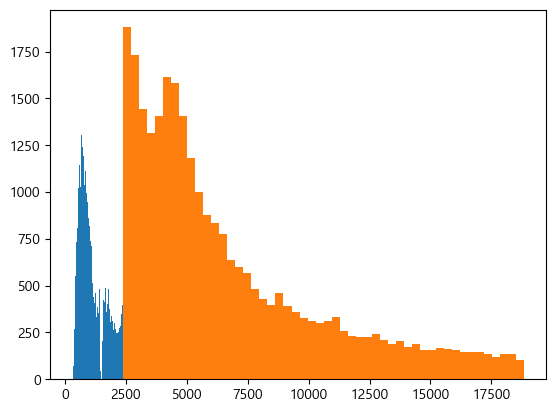

In [144]:
low_prices = diamonds[diamonds['price_level'] == 'low']['price']
high_prices = diamonds[diamonds['price_level'] == 'high']['price']

plt.hist(low_prices, bins=50)
plt.hist(high_prices, bins=50)
plt.show()

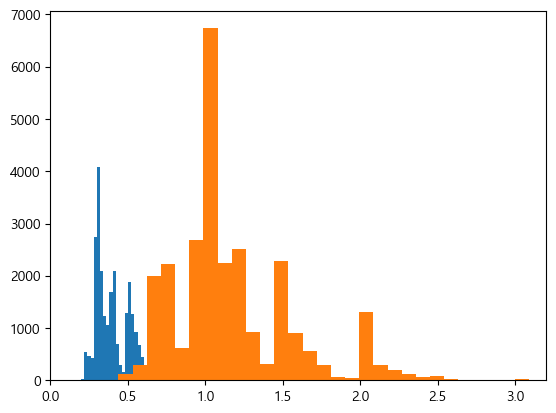

In [145]:
low_prices_c = diamonds[diamonds['price_level'] == 'low']['carat']
high_prices_c = diamonds[diamonds['price_level'] == 'high']['carat']

plt.hist(low_prices_c, bins=50)
plt.hist(high_prices_c, bins=50)
plt.xlim(0, 3.2)
plt.show()

<h2>Heatmap 히트맵

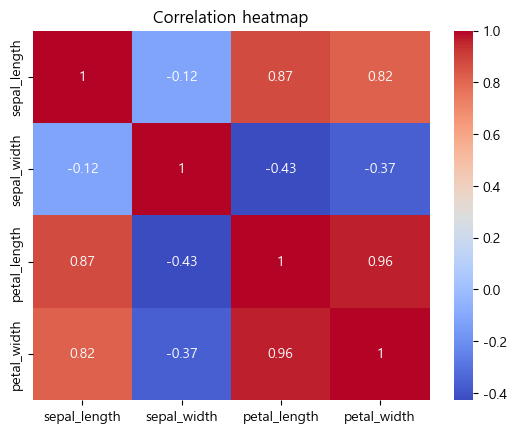

In [146]:
corr = iris.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation heatmap")
plt.show()

<h2>Pie Plot 파이플롯, 원차트

In [147]:
iris

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


<Axes: ylabel='0'>

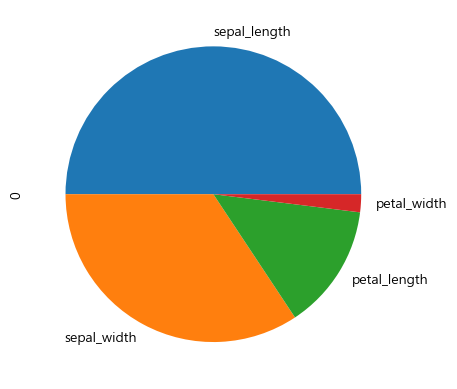

In [148]:
iris.iloc[0].plot.pie()

array([<Axes: ylabel='0'>, <Axes: ylabel='1'>, <Axes: ylabel='2'>],
      dtype=object)

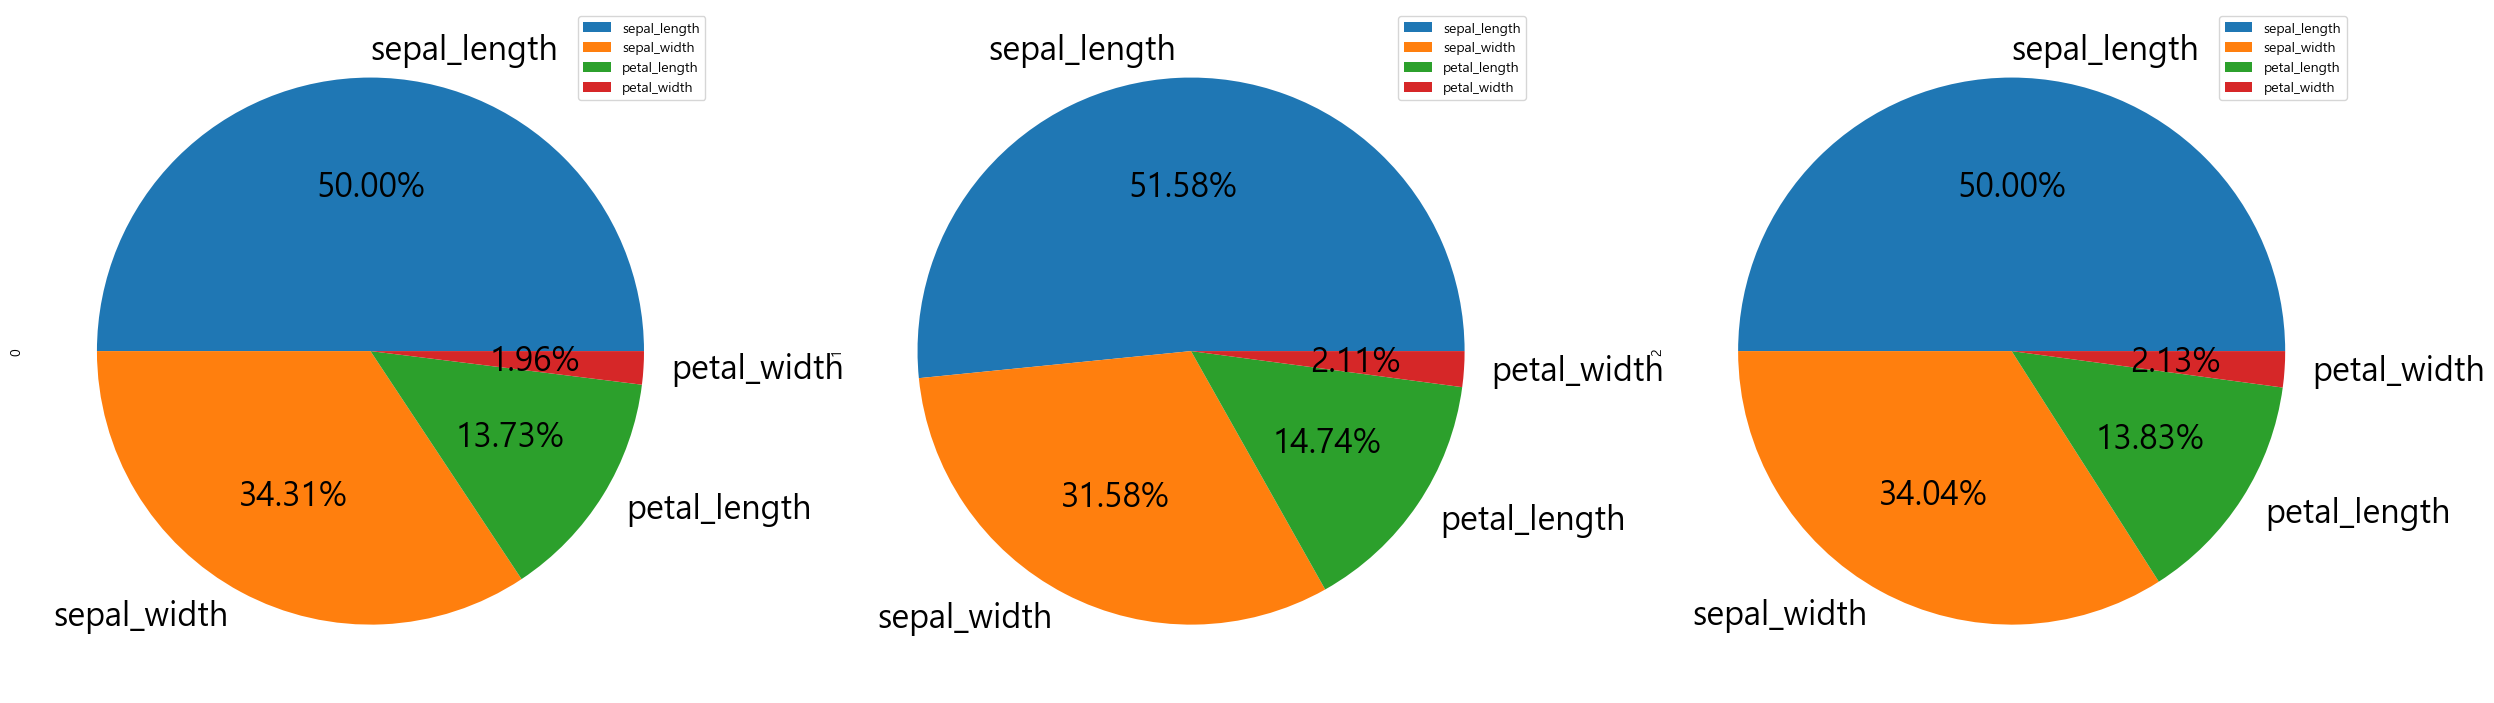

In [149]:
d = iris.head(3).T
d.plot.pie(subplots=True, figsize=(30,30), fontsize=24, autopct="%.2f%%")
# 2개 이상의 열로 구성된 DataFrame의 원차트를 그릴 때 subplots=True 옵션을 사용하지 않으면 에러발생

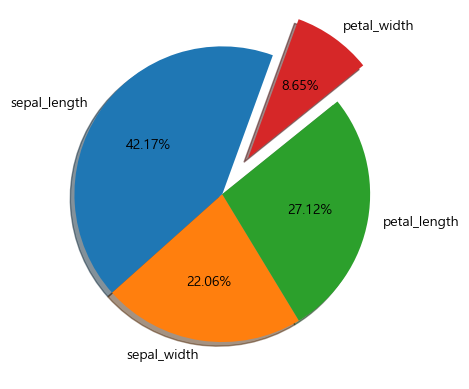

In [150]:
iris_m = iris.mean()
plt.pie(iris_m, labels= iris_m.index, autopct='%.2f%%', explode=(0,0,0,0.3)
        , startangle=70, shadow=True)
plt.show()
# labels : 각 데이터의 이름 배정
# autopct : 각 데이터의 비율을 백분율로 표기함
# explode : 부채꼴을 중앙으로부터 할당한 값만큼 벗어나게 함
# startangle : 첫 번째 데이터 영역이 시작하는 위치의 각도
# shadow : 그림자 사용 여부

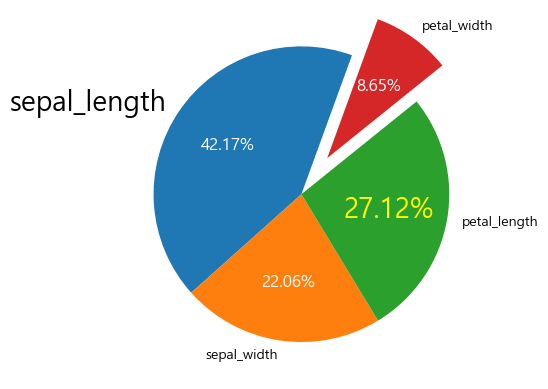

In [151]:
patches, texts, autotexts = plt.pie(iris_m, labels= iris_m.index, autopct='%.2f%%', explode=(0,0,0,0.3), startangle=70)
# patches : 원차트의 부채꼴 / texts : label에 해당하는 텍스트 / autotexts : 원차트 내부의 text
plt.setp(autotexts, size=12, color='white')
# plt.setp : text, axis, tick, legend 등 포함하는 artist object의 특성을 설정
autotexts[2].set_color('yellow')
autotexts[2].set_size(20)
texts[0].set_size(20)

plt.show()

<h2>Polar axis 극좌표계

반지름 r, 각도 theta 로 데이터 위치를 결정

방향성 데이터를 시각화 : 바람 방향, 레이더, 주기적 패턴

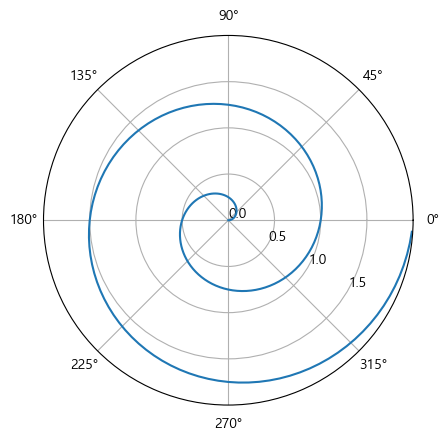

In [152]:
# 선차트 그리기

r = np.arange(0, 2, 0.01)
theta = 2 * np.pi * r

plt.figure(dpi=100) # dpi : 이미지 해상도 (높을수록 선명)
ax = plt.subplot(111, projection='polar')
# plt.subplot(111) : 서브플롯 구성 (nrows=1, ncols=1, index=1) → 전체 1행 1열짜리 그림에서 첫 번째 그래프라는 의미
# projection='polar' : 이 축(ax)을 극좌표계로 그리겠다는 설정 (극축 생성)
ax.plot(theta, r) # 각도(theta)와 반지름(r)을 통해 선차트를 그림
ax.set_rmax(2) # 반지름의 최대값
ax.set_rticks([0, 0.5, 1, 1.5]) # 눈금 값
ax.set_rlabel_position(-30) # 반지름 축 라벨의 위치
plt.show()

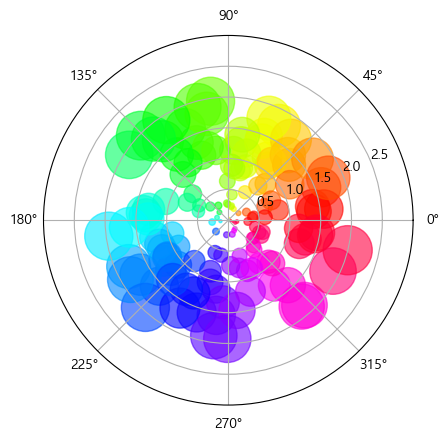

In [153]:
# 분산형차트 그리기

np.random.seed(0) # seed(0) 으로 난수값 고정

N = 150
r = 2 * np.random.rand(N) # 0과 2사이의 임의의 값 150개 생성
theta = 2 * np.pi * np.random.rand(N) # 0과 2π 사이의 임의의 각도 150개 생성
area = 50 * 2 * np.pi * r**2 # 각 데이터(r)에 대한 원(마커)의 면적 나타냄
colors = theta # 각도를 기반으로 마커의 색을 다르게 지정해서, 방향 정보가 색으로 표현되도록 만듦

fig = plt.figure(dpi=100)
ax = fig.add_subplot(111, projection='polar')
c = ax.scatter(theta, r, c = colors, s = area, cmap = 'hsv', alpha = 0.6)
# theta, r : 데이터 / c : 마커 색상 / s : 마커 크기 / cmap : 마커의 색상 결정할 컬러맵 / alpha : 투명도
ax.set_rmax(3)
ax.set_rticks([0.5, 1, 1.5, 2, 2.5])

plt.show()

<BarContainer object of 20 artists>

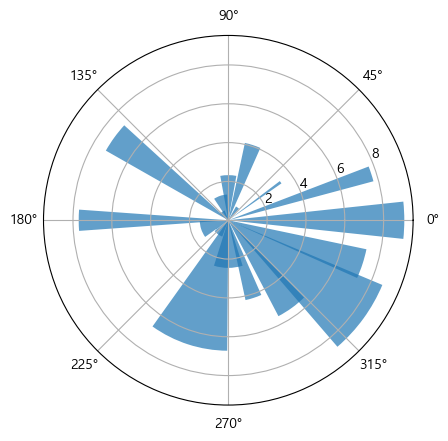

In [154]:
# 막대차트 그리기

N = 20
theta = np.linspace(0.0, 2*np.pi, N, endpoint=False) # endpoint=False : 끝점 포함 안함
# 0부터 2π(한 바퀴)까지의 범위를 균등하게 N개로 나눈 각도 배열을 생성
radii = 10 * np.random.rand(N) # 각 막대의 길이(=반지름 방향 크기)를 0~10 사이의 난수로 생성
width = np.pi / 4 * np.random.rand(N) # 각 막대의 넓이(=각도 폭)를 0~π/4 사이의 난수로 생성

ax = plt.subplot(1, 1, 1, projection = 'polar')
ax.bar(theta, radii, width = width, alpha = 0.7)
# ax.bar(x, height, width) : x는 각도, height는 부채꼴의 반지름, width는 부채꼴의 각도에 대응

<h2>Time Series 시계열

In [155]:
df = pd.read_csv('nyc_temp.csv', parse_dates=['date']) # parse_dates : datetime 형태로 변환
df.set_index('date', inplace=True) # inplace=True : 원본 객체를 직접 수정
df.head()

,temp
date,
1869-01-01,-17
1869-01-02,-28
1869-01-03,17
1869-01-04,28
1869-01-05,61


<Axes: xlabel='date'>

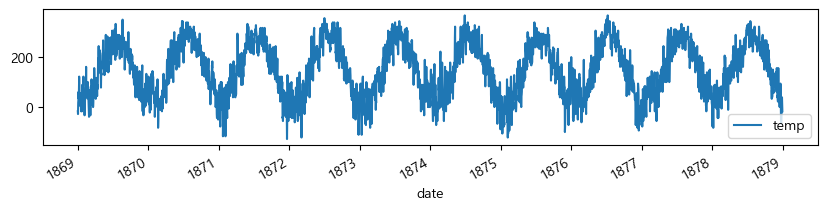

In [156]:
df.plot(figsize=(10,2))

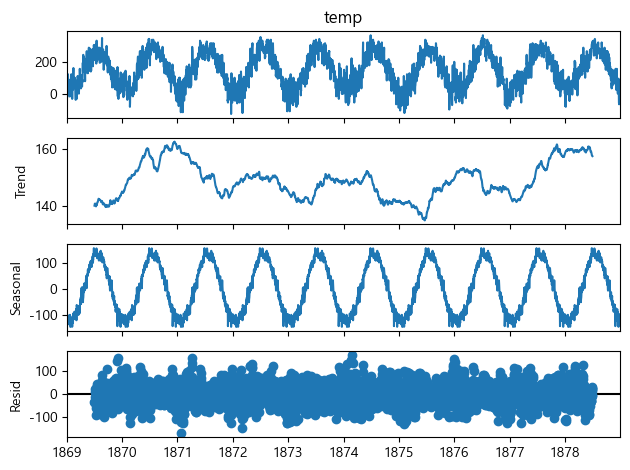

In [157]:
# Time Series Decomposition (시계열 분해)

from statsmodels.tsa.seasonal import seasonal_decompose
# 가법 모델(Additive model) : 데이터가 일정한 변동 폭을 가질 때 사용
results = seasonal_decompose(df['temp'], period=365)
results.plot()
plt.show()
# resid = results.resid.dropna()
# -> 시계열 분해에서 생긴 잔차(residual) 데이터에서 NaN을 제거하여 분석이나 시각화에 쓸 수 있게 정리하는 코드

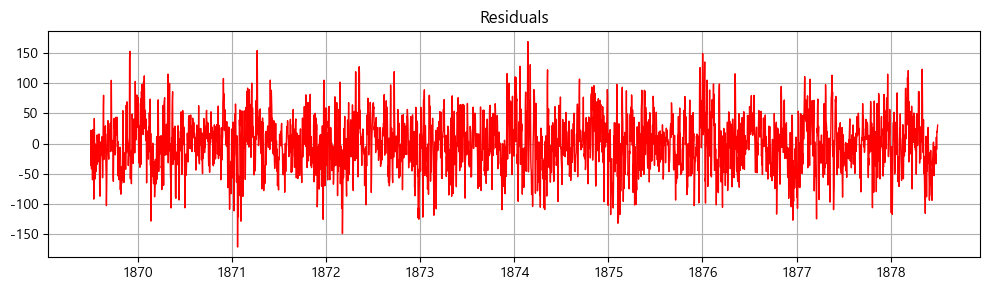

In [158]:
plt.figure(figsize=(10,3))
plt.plot(results.resid, color='red', linewidth=1)
# results.resid : seasonal_decompose()로 분해한 후 나온 잔차 시계열
plt.title('Residuals')
plt.grid(True)
plt.tight_layout()
plt.show()

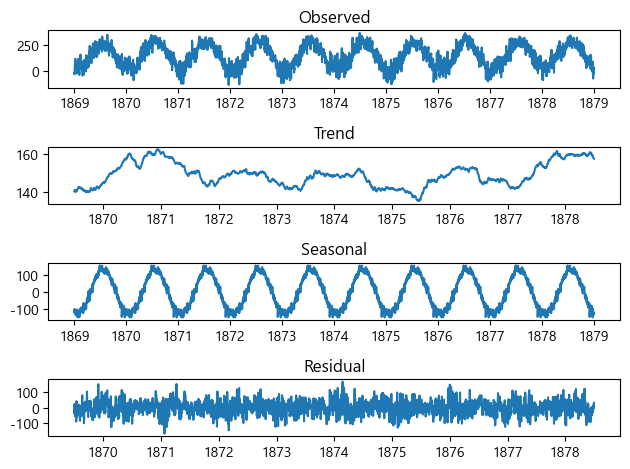

In [159]:
fig, axes = plt.subplots(4,1)

components = [results.observed, results.trend, results.seasonal, results.resid]
titles = ['Observed', 'Trend', 'Seasonal', 'Residual']

for i, comp in enumerate(components): # enumerate : 인덱스 번호와 값(요소)을 함께 반환하는 함수
    axes[i].plot(comp)
    axes[i].set_title(titles[i])

plt.tight_layout()
plt.show()

<h2>연습문제

In [160]:
# 1. titanic 데이터셋을 이용해 수치형 변수 간의 상관관게를 히트맵으로 시각화하시오.

titanic = sns.load_dataset('titanic')
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


<Axes: >

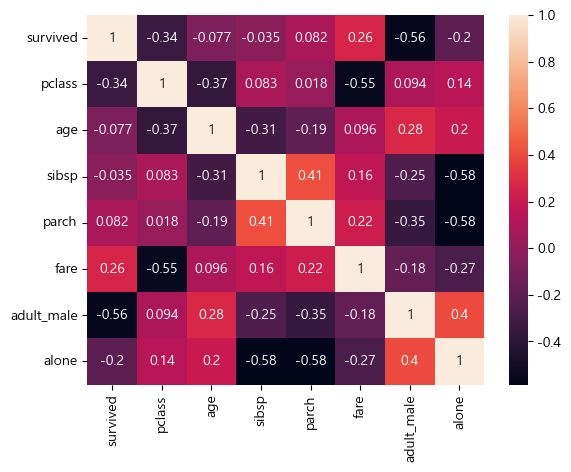

In [161]:
titanic_num = titanic.corr(numeric_only=True)
sns.heatmap(titanic_num, annot=True)

In [ ]:
# 시험 당일 실행점 위치 flag (맨 윗줄 실행 후 실행)
# 2. tips데이터에서 요일별 방문 횟수 비율을 파이차트로 시각화하시오.

In [3]:
tips = sns.load_dataset('tips')
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [7]:
tips['day'].unique()

['Sun', 'Sat', 'Thur', 'Fri']
Categories (4, object): ['Thur', 'Fri', 'Sat', 'Sun']

In [22]:
count = []
for day in tips['day'].unique() :
    count.append(tips[tips['day'] == day]['tip'].count())

count

[76, 87, 62, 19]

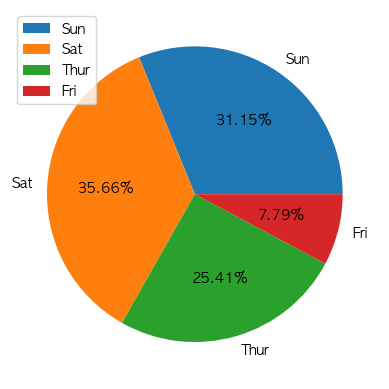

In [25]:
plt.pie(count, labels = tips['day'].unique(), autopct='%.2f%%')
plt.legend()
plt.show()

In [ ]:
# 3. flights의 passengers를 월별로 시계열 분해한 후 그래프를 그려 해석하시오.

In [3]:
flights = sns.load_dataset('flights')
flights

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121
...,...,...,...
139,1960,Aug,606
140,1960,Sep,508
141,1960,Oct,461
142,1960,Nov,390


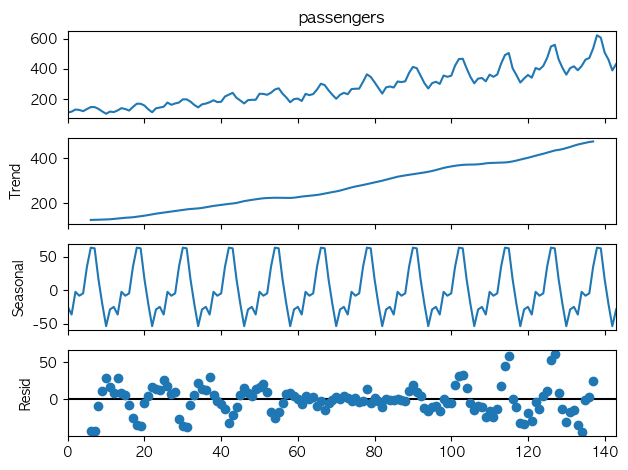

In [8]:
results = seasonal_decompose(flights['passengers'], period=12)
results.plot()
plt.show()

In [ ]:
# 4. flights데이터에서 1950~1952년까지의 월별 승객수를 극좌표(ploar axis)그래프로 시각화하시오.

In [44]:
flights = sns.load_dataset('flights')

flights_5052 = flights[(flights['year'] >= 1950) & (flights['year'] <= 1952)]
flights_5052

,year,month,passengers
12,1950,Jan,115
13,1950,Feb,126
14,1950,Mar,141
15,1950,Apr,135
16,1950,May,125
17,1950,Jun,149
18,1950,Jul,170
19,1950,Aug,170
20,1950,Sep,158
21,1950,Oct,133


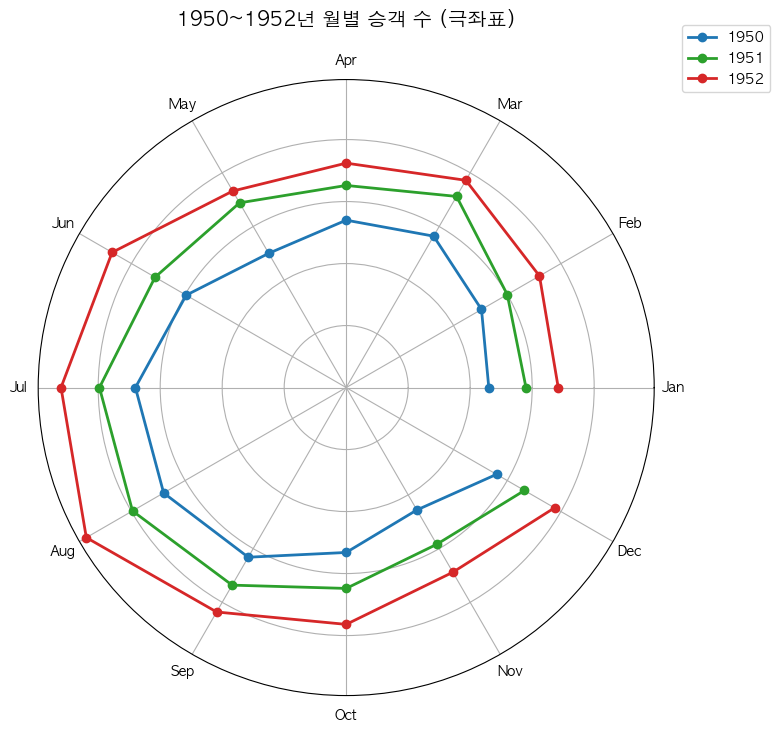

In [ ]:
# 2. 1950~1952년 데이터만 필터
flights = flights[flights['year'].between(1950, 1952)]

# 3. 월을 숫자로 변환 (Jan=0, Feb=1, ..., Dec=11)
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
            'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
flights['month'] = pd.Categorical(flights['month'], categories=month_order, ordered=True)
flights['month_num'] = flights['month'].cat.codes

# 4. 극좌표용 그래프 준비
plt.figure(figsize=(8, 8))
ax = plt.subplot(111, projection='polar')

colors = ['#1f77b4', '#2ca02c', '#d62728']  # 연도별 색상

# 5. 연도별로 그래프 그리기
for i, year in enumerate(sorted(flights['year'].unique())):
    data = flights[flights['year'] == year]
    theta = 2 * np.pi * data['month_num'] / 12
    r = data['passengers'].values
    ax.plot(theta, r, label=str(year), color=colors[i], marker='o', linewidth=2)

# 6. 눈금 설정 및 출력
ax.set_xticks(np.linspace(0, 2*np.pi, 12, endpoint=False))
ax.set_xticklabels(month_order)
ax.set_yticklabels([])
ax.set_title('1950~1952년 월별 승객 수 (극좌표)', fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.show()

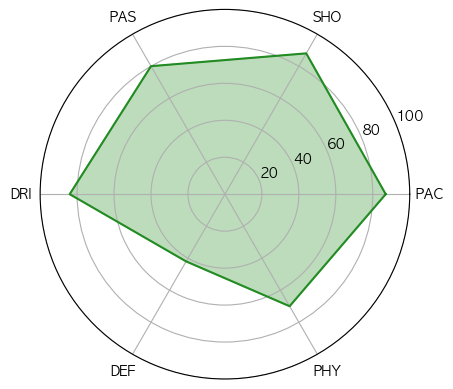

In [47]:
# 요건 그냥 polor axis 관련해서 추가로

stats = ["PAC", "SHO", "PAS", "DRI", "DEF", "PHY"]
theta = np.linspace(0, 2*np.pi, 6, endpoint=False) 
son = np.array([87, 88, 80, 84, 42, 70])

# 끝의 점끼리 연결
son = son.tolist() + [son[0]]
theta = theta.tolist() + [theta[0]]

fig = plt.figure()
ax = fig.add_subplot(111, projection='polar')

ax.plot(theta, son, color='forestgreen')
ax.fill(theta, son, alpha=0.3, color='forestgreen')
ax.set_thetagrids([n*60 for n in range(6)], stats)
ax.set_rmax(100)
plt.show()

<h2>Strip Chart 스트립 차트

In [48]:
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


/var/folders/bg/09yqnt111t34m8ws2pzns7yh0000gn/T/ipykernel_68659/1081245002.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x = 'day', y = 'total_bill', data = tips, palette = 'Set2')


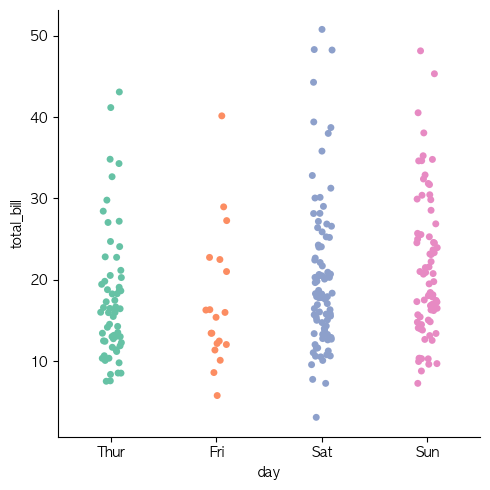

In [ ]:
sns.catplot(x = 'day', y = 'total_bill', data = tips, palette = 'Set2')
# sns.stripplot() 과 동일

/var/folders/bg/09yqnt111t34m8ws2pzns7yh0000gn/T/ipykernel_68659/1855447433.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x = 'total_bill', y = 'day', data = tips, palette = 'Set2')


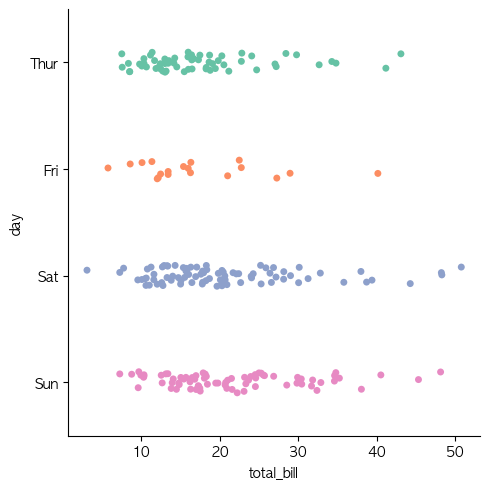

In [61]:
sns.catplot(x = 'total_bill', y = 'day', data = tips, palette = 'Set2')

/var/folders/bg/09yqnt111t34m8ws2pzns7yh0000gn/T/ipykernel_68659/3348933926.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x = 'day', y = 'total_bill', data = tips,


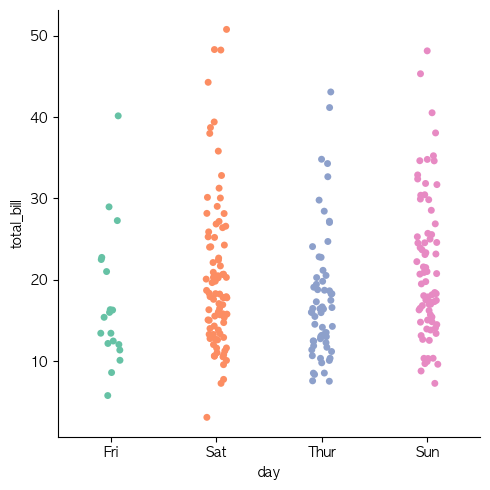

In [ ]:
sns.catplot(x = 'day', y = 'total_bill', data = tips,
            order = ['Fri', 'Sat', 'Thur', 'Sun'], palette = 'Set2')
# order : 스트립차트의 순서 변경

/var/folders/bg/09yqnt111t34m8ws2pzns7yh0000gn/T/ipykernel_68659/1641868988.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x = 'day', y = 'total_bill', data = tips, jitter = False, palette = 'Set2')


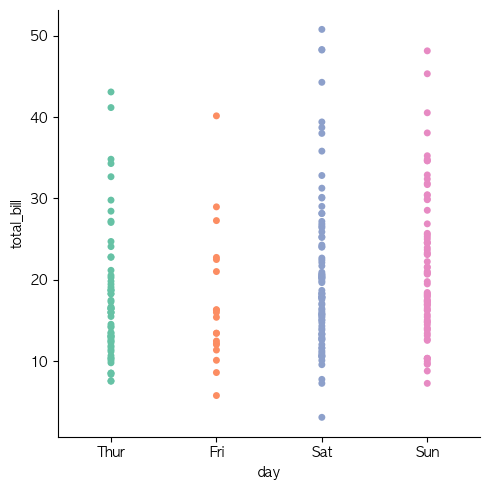

In [64]:
sns.catplot(x = 'day', y = 'total_bill', data = tips, jitter = False, palette = 'Set2')
# jitter = False : 데이터의 마커를 1열로 중첩하여 나열
# kind = 'swarm' : sns.swarmplot()과 동일

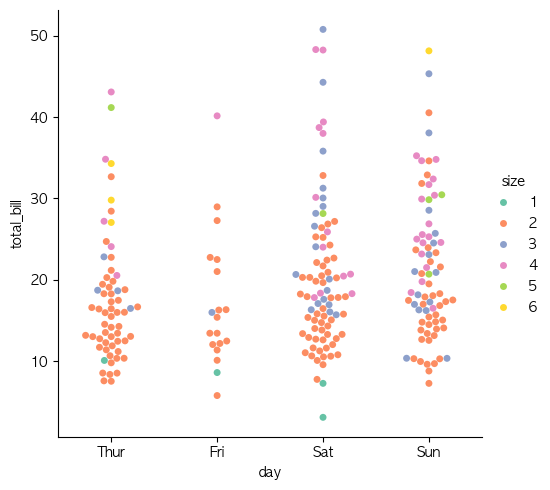

In [ ]:
sns.catplot(x = 'day', y = 'total_bill', data = tips, kind = 'swarm', hue = 'size', palette = 'Set2')
# hue : hue에 적용한 열의 값에 따라 다른 색상의 마커가 나타남

<h2>Boxen Chart 박슨차트

In [68]:
diamonds = sns.load_dataset('diamonds')
diamonds.shape

(53940, 10)

In [69]:
diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


/var/folders/bg/09yqnt111t34m8ws2pzns7yh0000gn/T/ipykernel_68659/779707089.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x = 'color', y = 'price', kind = 'boxen', data = diamonds, palette = 'Set3')


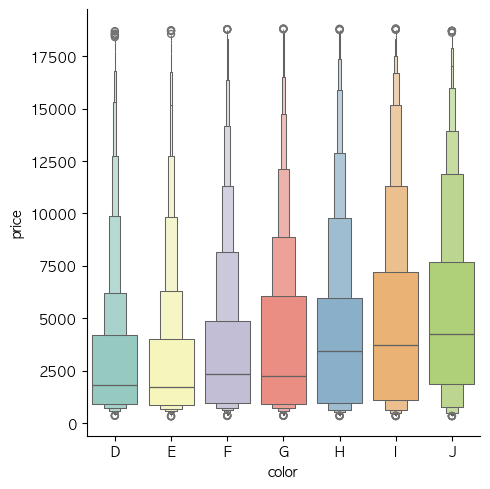

In [ ]:
sns.catplot(x = 'color', y = 'price', kind = 'boxen', data = diamonds, palette = 'Set3')
# kind = 'boxen' : sns.boxplot()과 동일

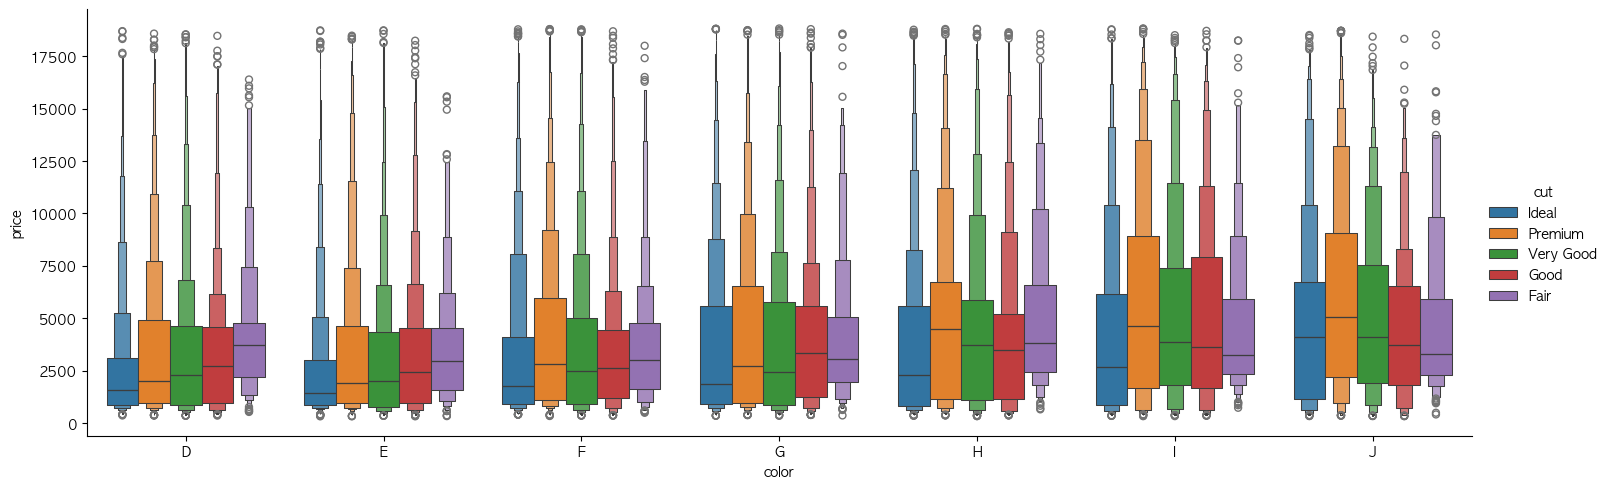

In [ ]:
sns.catplot(x = 'color', y = 'price', kind = 'boxen', data = diamonds,
            hue = 'cut', height = 5, aspect = 3)
# hue : hue열의 값에 따라 서로 다른 색상의 박슨 차트를 그림
# dodge = False : hue값에 따라 그려진 상자수염 차트가 중첩되어 그려짐

<h2>Violin Chart 바이올린 차트

/var/folders/bg/09yqnt111t34m8ws2pzns7yh0000gn/T/ipykernel_68659/1153920511.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x = 'total_bill', y = 'day', data = tips, kind = 'violin', palette = 'Set1')


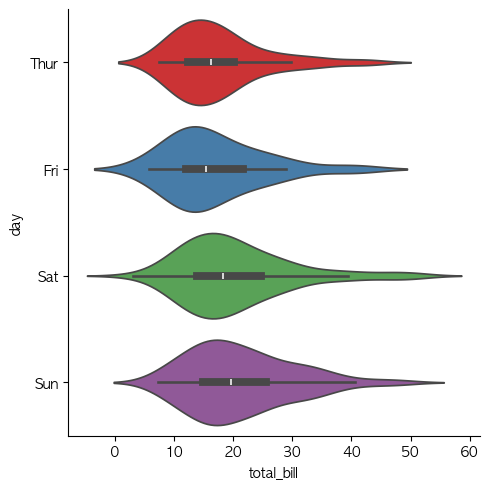

In [77]:
sns.catplot(x = 'total_bill', y = 'day', data = tips, kind = 'violin', palette = 'Set1')
# kind = 'violin' : sns.violinplot()와 동일

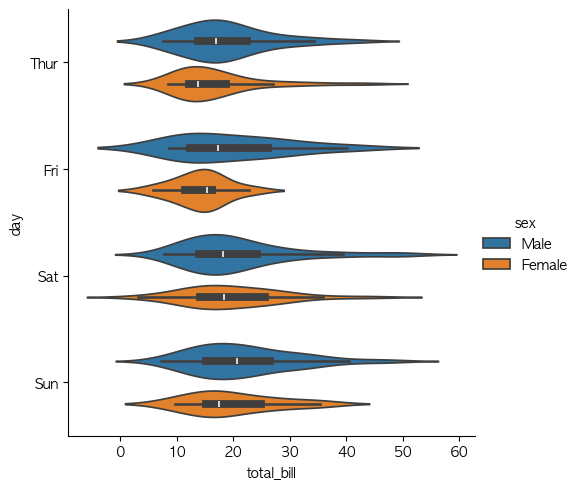

In [78]:
sns.catplot(x = 'total_bill', y = 'day', data = tips, kind = 'violin', hue = 'sex')
# hue : hue열에 따라 서로 다른 바이올린 차트를 그림

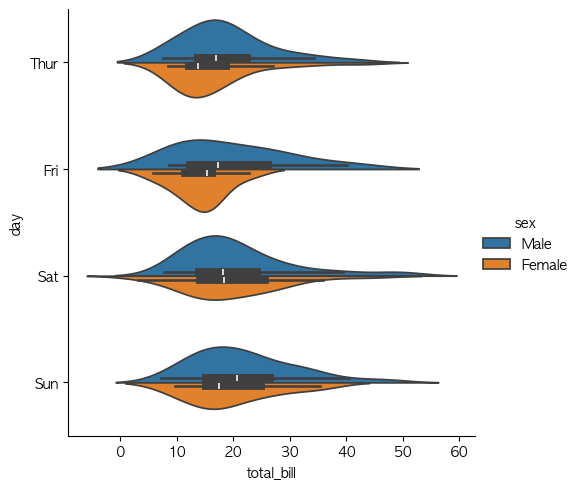

In [79]:
sns.catplot(x = 'total_bill', y = 'day', data = tips, kind = 'violin',
            hue = 'sex', split = True)
# split = True : 바이올린 차트가 반으로 나뉘어져 그려짐 (hue열 값에 따라, 두 종류일 경우에만)

<h2>Point plot 포인트차트

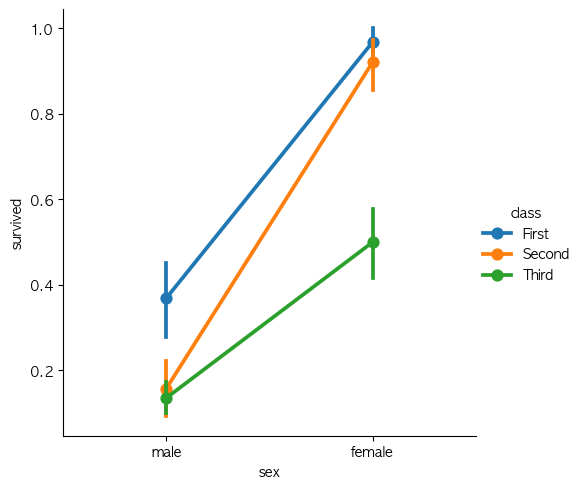

In [ ]:
titanic = sns.load_dataset('titanic')
sns.catplot(x = 'sex', y = 'survived', hue = 'class', kind = 'point', data = titanic)
# kind = 'point' : sns.pointplot()와 동일

<h2>연습문제

In [84]:
# 문제 1
# 성별에 따른 월평균 구매금액의 차이를 시각적으로 비교하여 분석하시오.

shopping_transaction = pd.read_csv('shopping_transaction.csv')
shopping_transaction

,고객ID,성별,나이,월구매금액,방문빈도,회원등급,구매채널
0,1001,여성,21,308513,9,Silver,온라인
1,1002,여성,54,108331,5,Bronze,오프라인
2,1003,여성,33,106956,22,Bronze,모바일
3,1004,여성,54,404472,13,Silver,오프라인
4,1005,여성,30,322842,9,Silver,오프라인
...,...,...,...,...,...,...,...
995,1996,여성,44,388097,6,Silver,모바일
996,1997,남성,30,282590,24,Bronze,온라인
997,1998,남성,23,267458,17,Silver,온라인
998,1999,남성,43,553351,25,Gold,온라인


/var/folders/bg/09yqnt111t34m8ws2pzns7yh0000gn/T/ipykernel_68659/3192875698.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x = '성별', y = '월구매금액', data = shopping_transaction,


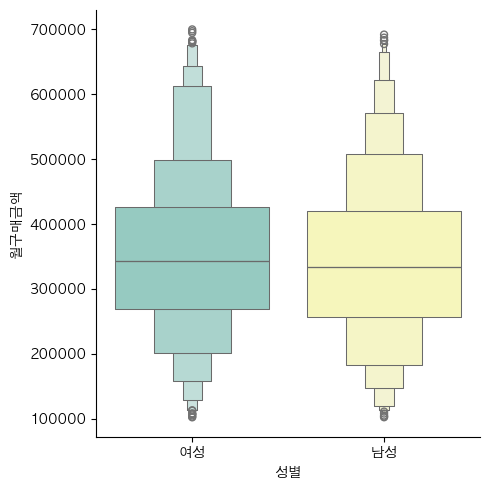

In [87]:
sns.catplot(x = '성별', y = '월구매금액', data = shopping_transaction,
            kind = 'boxen', palette = 'Set3')
plt.show()

/var/folders/bg/09yqnt111t34m8ws2pzns7yh0000gn/T/ipykernel_68659/2246522359.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x = '나이', y = '월구매금액', data = st, kind = 'strip', palette = 'Set2', aspect = 2,  jitter = False)


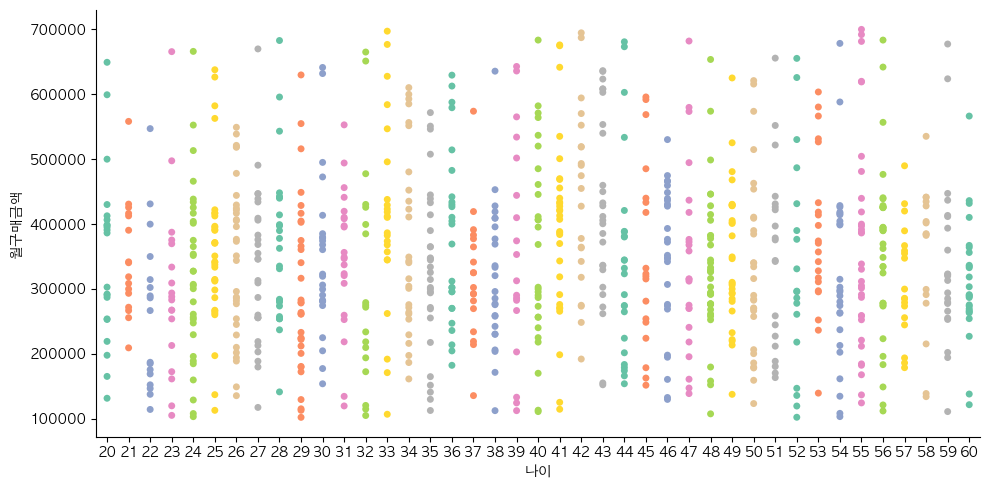

In [89]:
# 문제 2
# 나이와 월구매금액 간의 관계를 확인하기 위한 그래프를 시각화하고 분석하시오.

st = shopping_transaction
sns.catplot(x = '나이', y = '월구매금액', data = st, kind = 'strip', palette = 'Set2', aspect = 2,  jitter = False)

/var/folders/bg/09yqnt111t34m8ws2pzns7yh0000gn/T/ipykernel_68659/3684061742.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x = '회원등급', y = '월구매금액', data = st, kind = 'bar', palette = 'Set2')


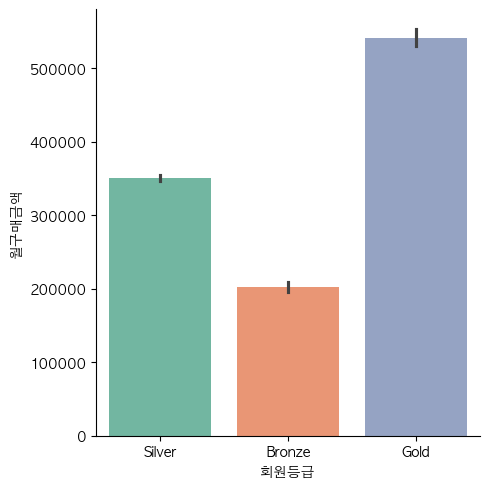

In [91]:
# 문제 3
# 회원등급별 월구매금액의 분포를 시각화하고 분석하시오.

sns.catplot(x = '회원등급', y = '월구매금액', data = st, kind = 'bar', palette = 'Set2')

/var/folders/bg/09yqnt111t34m8ws2pzns7yh0000gn/T/ipykernel_68659/2983918973.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x = '구매채널', y = '방문빈도', data = st, kind = 'box', palette = 'Set3')


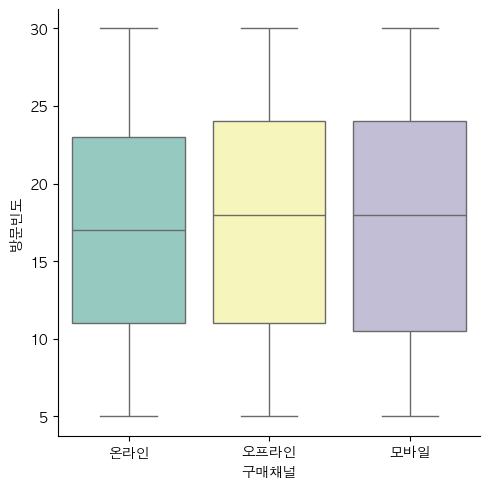

In [92]:
# 문제 4
# 구매채널(온라인/오프라인/모바일)에 따라 방문빈도가 다르게 나타나는지 시각화하고 분석하시오.

sns.catplot(x = '구매채널', y = '방문빈도', data = st, kind = 'box', palette = 'Set3')

In [93]:
# 문제 5
# 고객들의 나이를 20대, 30대, 40대, 50대 이상으로 나누어 연령대별 평균 구매금액을 구하시오.
# 가장 구매력이 높은 연령대는?

st_age = []
for i in range(2, 6) :
    age = i*10
    st_age.append(round((st[st['나이'] >= age])['월구매금액'].mean()))
    if i == 5 :
        print(f'50대 이상 : {st_age[i-2]}')
    else :
        print(f'{age}대 : {st_age[i-2]}')

print(f'\n구매력이 높은 연령대 : {(st_age.index(max(st_age))+2)* 10}대')

20대 : 347431
30대 : 353143
40대 : 354318
50대 이상 : 341931

구매력이 높은 연령대 : 40대


In [94]:
def Correlation(corr) :
    if corr == 1.0 :
        result = '완벽한 양의 상관관계'
    elif corr >= 0.7 :
        result = '강한 양의 상관관계'
    elif corr >= 0.4 :
        result = '뚜렷한 양의 상관관계'
    elif corr >= 0.2 :
        result = '약한 양의 상관관계'
    elif corr > 0 :
        result = '거의 없는 상관관계'
    elif corr == 0 :
        result = '상관 없음'
    elif corr > -0.4 :
        result = '약한 음의 상관관계'
    elif corr > -0.7 :
        result = '뚜렷한 음의 상관관계'
    elif corr > -1.0 :
        result = '강한 음의 상관관계'
    else :
        result = '완벽한 음의 상관관계'
    return result

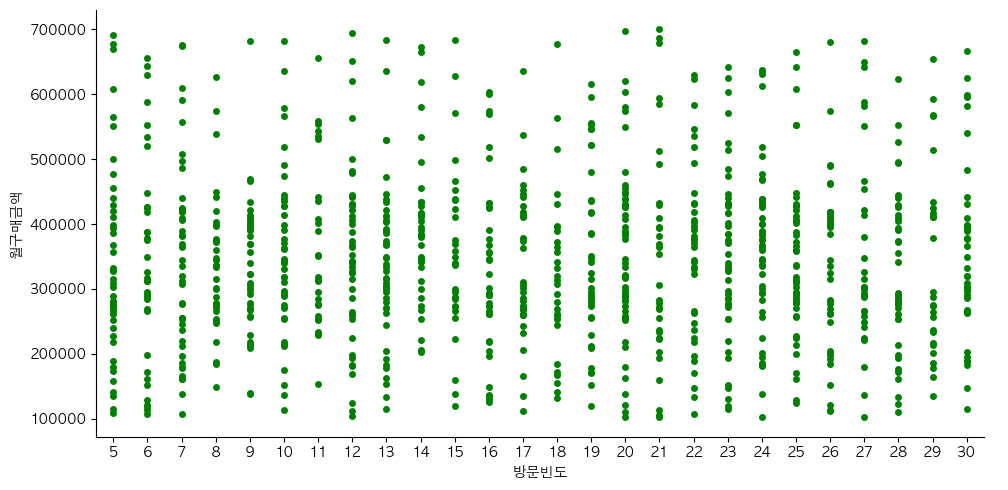

상관계수 : 0.01
고객들의 방문 빈도와 월구매금액은 거의 없는 상관관계를 가진다.


In [95]:
# 문제 6
# 고객들의 방문빈도와 구매금액 사이에 상관관계가 있는가? 상관계수와 함께 해석하시오.

from scipy.stats import pearsonr

corr, p = pearsonr(st['방문빈도'], st['월구매금액'])

sns.catplot(x = '방문빈도', y = '월구매금액', data = st, kind = 'strip', jitter = False, aspect = 2, color = 'green')
plt.show()

print(f'상관계수 : {corr:.2f}')
print('고객들의 방문 빈도와 월구매금액은 '+Correlation(corr)+'를 가진다.')

In [96]:
# 문제 7
# 고객의 회원등급이 높을수록 월구매금액이 높은지를 확인하시오. (Gold > Silver > Bronze로 가정)
# 상관계수와 함께 해석하시오.

grade_map = {'Bronze': 1, 'Silver': 3, 'Gold': 5}
st['등급숫자'] = st['회원등급'].map(grade_map)

corr, p = pearsonr(st['등급숫자'], st['월구매금액'])

print(f'상관계수 : {corr:.2f}')
print('고객의 회원등급과 월구매금액은 '+Correlation(corr)+'를 가진다.')

상관계수 : 0.88
고객의 회원등급과 월구매금액은 강한 양의 상관관계를 가진다.


In [97]:
# 문제 8
# 구매채널에 따른 평균 구매금액을 비교하고, 어떤 채널에서 구매금액이 가장 높은지 파악하시오.

channel_avg = st.groupby('구매채널')['월구매금액'].mean().round(2)
print(channel_avg)

# 최대 채널 출력
channel_max = channel_avg.idxmax()
print(f'\n가장 구매금액이 높은 채널: {channel_max}')

구매채널
모바일     348252.18
오프라인    349385.87
온라인     344456.86
Name: 월구매금액, dtype: float64

가장 구매금액이 높은 채널: 오프라인


<h2>Count Plot 카운트차트

In [103]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


/var/folders/bg/09yqnt111t34m8ws2pzns7yh0000gn/T/ipykernel_68659/686410935.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(kind = 'count', x = 'class', data = titanic, palette = 'Set1')


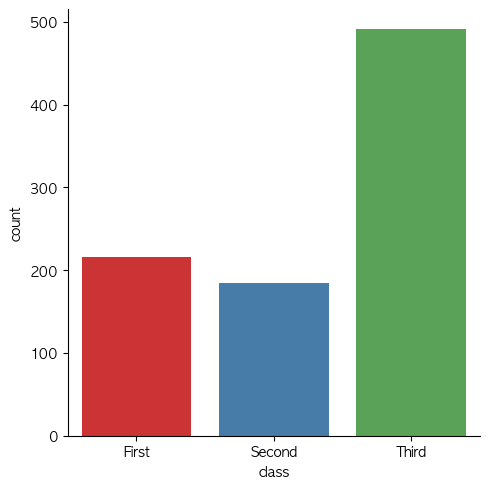

In [100]:
sns.catplot(kind = 'count', x = 'class', data = titanic, palette = 'Set1')

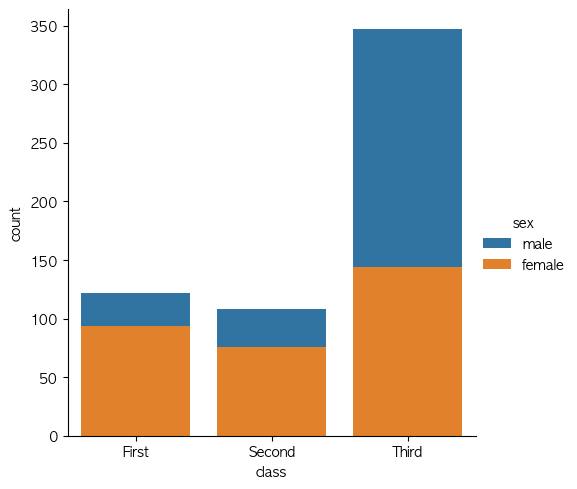

In [101]:
sns.catplot(kind = 'count', x = 'class', hue = 'sex', dodge = False, data = titanic)
# dodge = False : hue값에 따라 서로 다른 색상으로 누적된 막대 차트를 그림

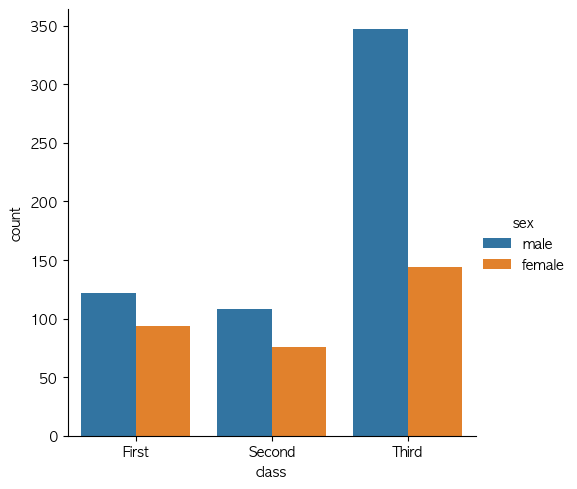

In [104]:
sns.catplot(kind = 'count', x = 'class', hue = 'sex', data = titanic)

<h2>Distplot 커널밀도 차트

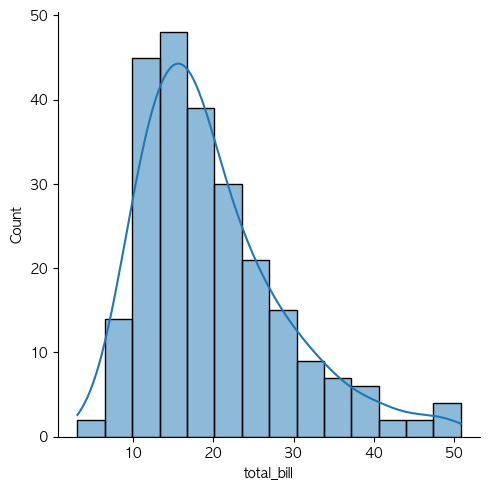

In [107]:
sns.displot(tips['total_bill'], kde = True)

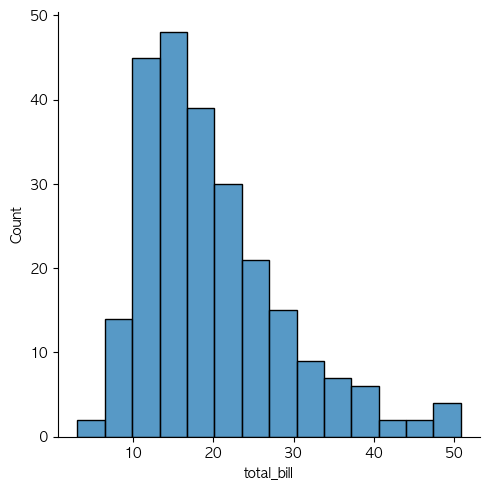

In [109]:
sns.displot(tips['total_bill'], kde = False)

AttributeError: Rectangle.set() got an unexpected keyword argument 'hist'

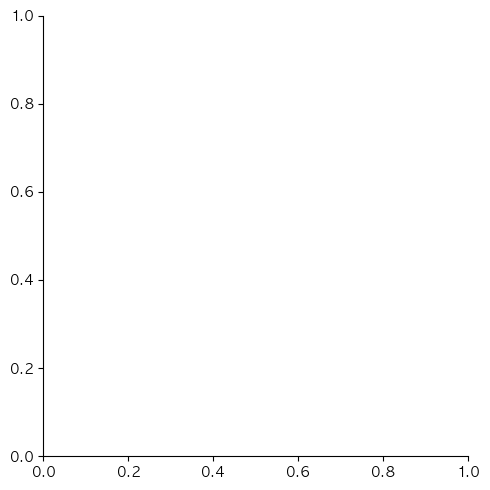

In [ ]:
sns.displot(tips['total_bill'], hist = False)
# 이거 교수님께 질문드리기ㅠㅠ

<h2>Jointplot 조인트차트

In [112]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


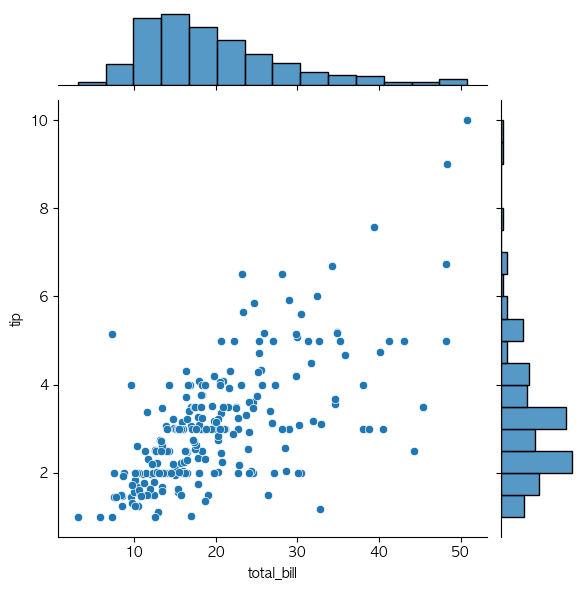

In [113]:
sns.jointplot(x = 'total_bill', y = 'tip', data = tips)
# x축과 y축에 지정된 각 열에 대해 분산형 차트를 그리고 x와 y에 대한 히스토그램을 그림

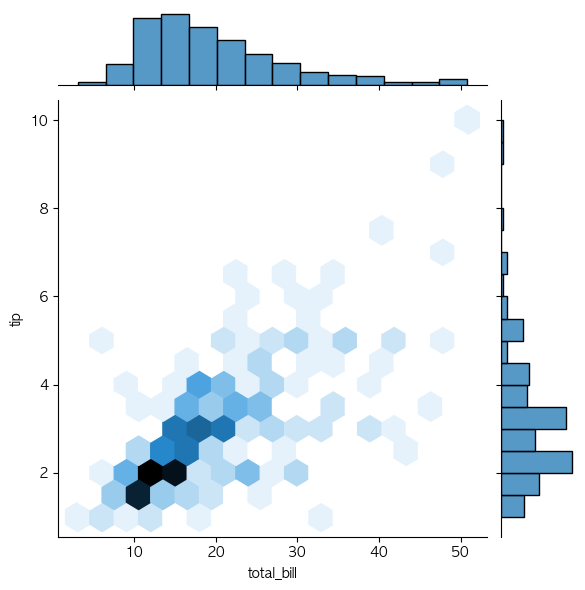

In [114]:
sns.jointplot(x = 'total_bill', y = 'tip', data = tips, kind = 'hex')
# kind = 'hex' : x축과 y축 열에 대해 육각형비닝차트를 그림

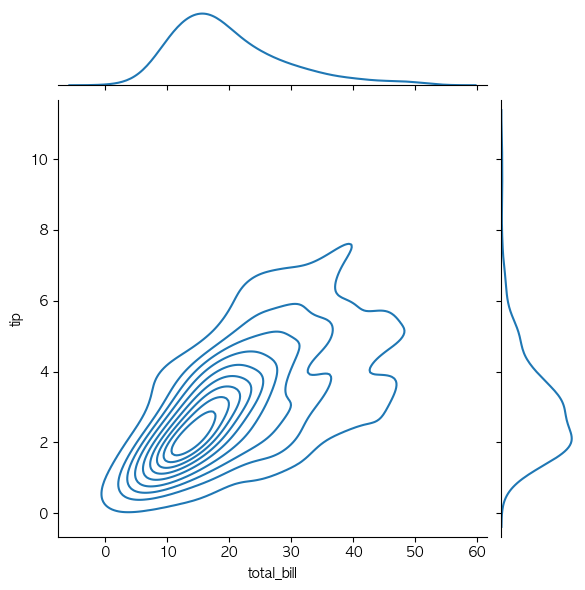

In [115]:
sns.jointplot(x = 'total_bill', y = 'tip', data = tips, kind = 'kde')
# kind = 'kde' : 분산형차트와 히스토그램 대신 커널밀도 곡선을 그림

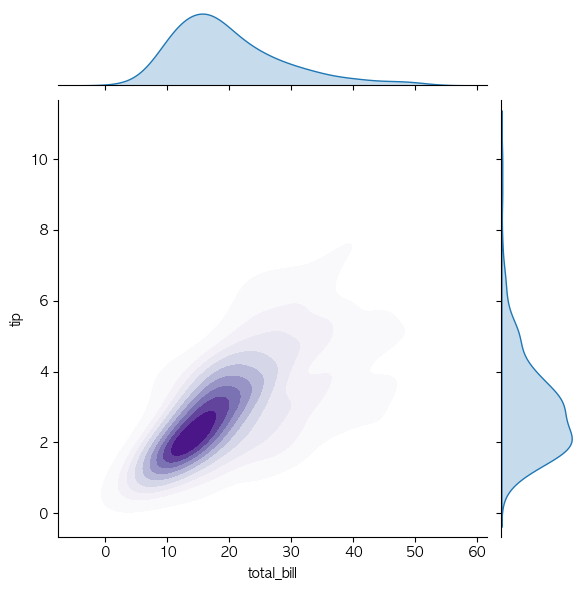

In [120]:
sns.jointplot(x = 'total_bill', y = 'tip', data = tips, kind = 'kde',
            fill = True, cmap = 'Purples')
# kind = 'kde', fill = True : 커널밀도곡선 내부 색상 설정이 가능하며, cmap을 통해 색상 지정 가능

<h2>Pairplot 페어차트

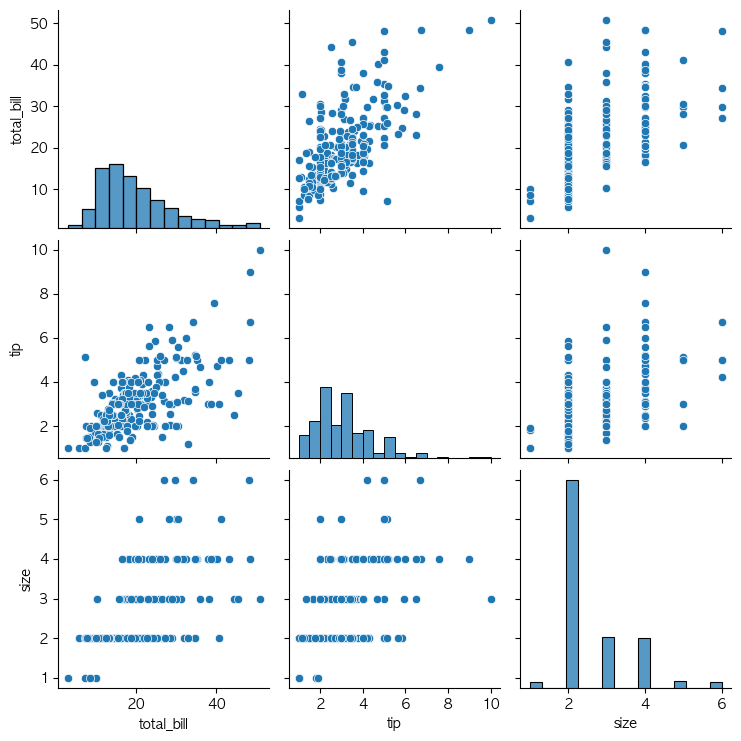

In [122]:
sns.pairplot(tips)
# DataFrame의 특성(열) 중 요소 값이 숫자인 특성 간의 관계를 차트로 나타냄

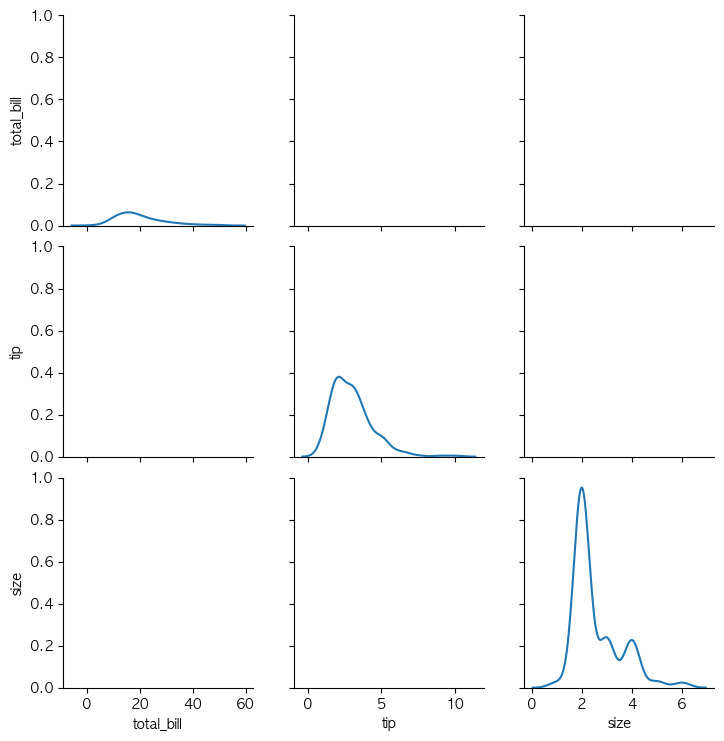

In [130]:
g = sns.PairGrid(tips)
g.map_diag(sns.kdeplot)
# PairGrid는 axis만 그려주며, map_diag는 대각 위치의 차트를 그림
# g.map_diag(sns.histplot) : 히스토그램, g.map_diag(sns.kdeplot) : 커널밀도곡선

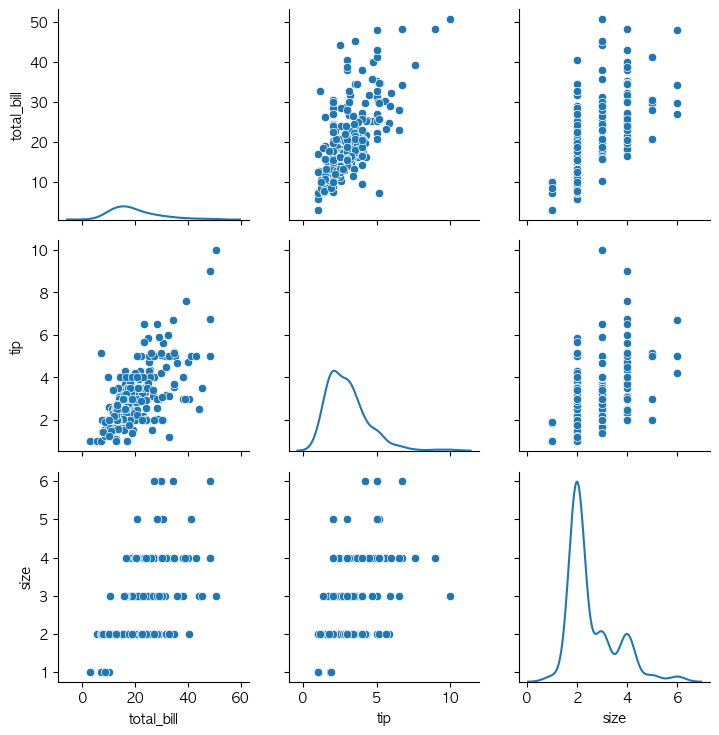

In [131]:
g = sns.PairGrid(tips)
g.map_diag(sns.kdeplot)
g.map_offdiag(sns.scatterplot)
# map_offdiag는 서로 다른 특성 간 차트 그림

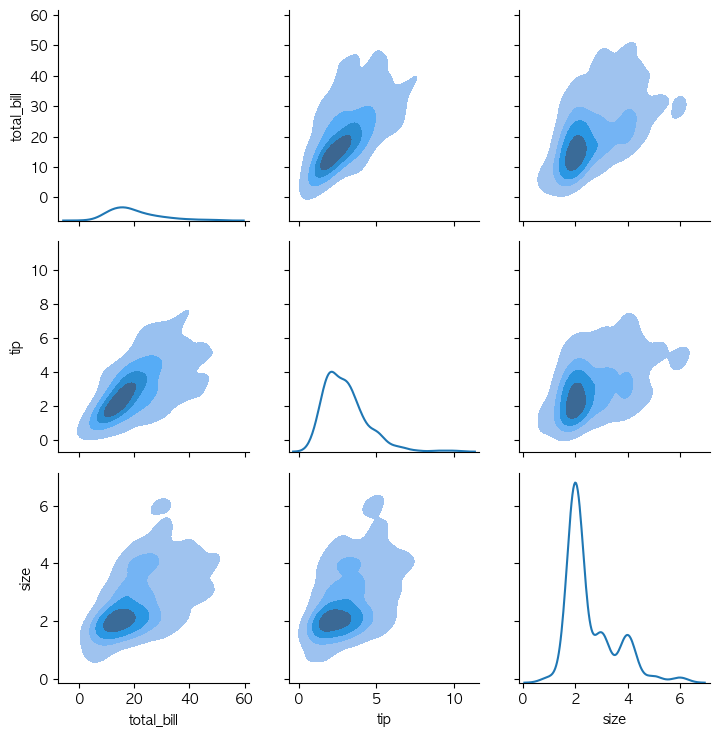

In [132]:
g = sns.PairGrid(tips)
g.map_diag(sns.kdeplot)
g.map_offdiag(sns.kdeplot, n_levels = 5, fill = True)
# g.map_diag(sns.kdeplot) : 대각선(변수 자기 자신)에는 커널 밀도 함수(KDE) 그래프를 그림.
# g.map_offdiag(sns.kdeplot) : 비대각선(다른 변수 간 조합)에는 2D KDE 밀도 곡선을 그림.
# n_levels=5 : 밀도 곡선을 5단계 contour로 나눔, fill=True : contour 영역을 색상으로 채움 → 컬러 등고선 형태

<h2>Regplot 선형회귀

산점도 (scatter plot) 위에 회귀선 (regression line)과 신뢰구간 (confidence interval) 함께 표시

In [135]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


<Axes: xlabel='total_bill', ylabel='tip'>

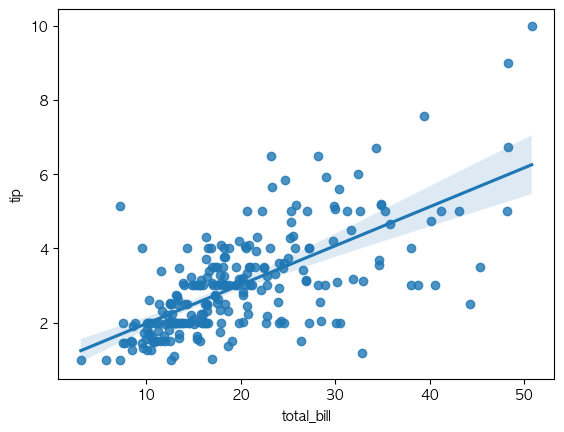

In [133]:
sns.regplot(x = 'total_bill', y = 'tip', data = tips)

<Axes: xlabel='size', ylabel='tip'>

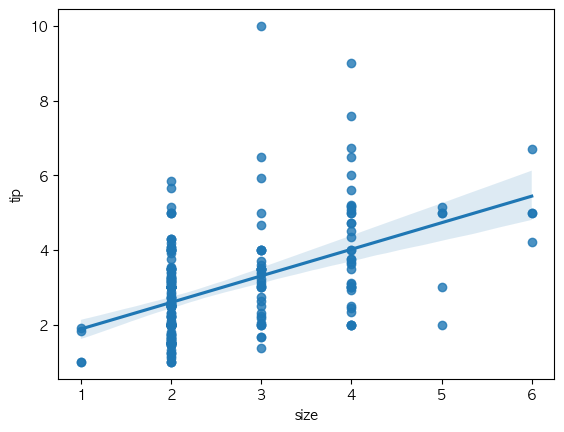

In [134]:
sns.regplot(x = 'size', y = 'tip', data = tips)
# 범주형 데이터를 사용한 선형회귀 분석도 가능

<Axes: xlabel='size', ylabel='tip'>

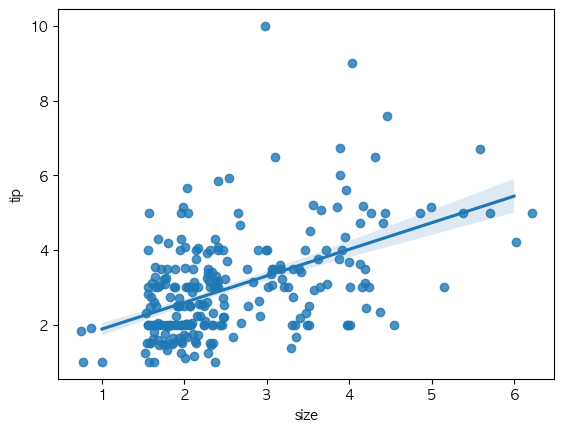

In [136]:
sns.regplot(x = 'size', y = 'tip', data = tips, x_jitter = 0.5, ci = 80)
# x_jitter : 지정된 값 크기의 균일 분포를 따르는 임의의 노이즈를 변수에 추가 (y_jitter도 있음)
# 임의의 노이즈는 선형회귀 분석 이후 추가되므로 회귀 분석 결과에는 영향 X, 데이터의 분산 형태만 변경
# 직선 주위의 영역은 신뢰구간 의미, ci = x 옵션으로 변경 (default는 95)

<h2>가설 검정</h2>
- 데이터를 바탕으로 어떤 주장(가설) 이 통계적으로 타당한지를 검증하는 절차
<h5>귀무가설(Null Hypothesis, H0) 과 대립가설(Alternative Hypothesis, H1) 설정

- H0 (귀무가설) : '차이가 없다' 거나 '효과가 없다' 는 기본 가정
- H1 (대립가설) : '차이가 있다' 거나 '효과가 있다' 고 주장하는 가설
- ex) 신약의 효과를 검정할 때 - H0 : 신약과 기존 약물의 평균 효과에 차이가 없다, H1 : 신약이 기존 약물보다 효과가 크다

<h5>유의수준(α, alpha) 결정</h5>

- 흔히 0.05(%)나 0.01(%)를 사용
- α는 제 1종 오류 (Type 1 error), 즉 실제로 H0이 참인데 이를 기각할 확률
- 작게 설정할수록 거짓 경보를 줄이지만 제 2종 오류 (Type 2 error, β) 가능성 (실제로 효과가 있는데 검출 못 함)은 커짐

<h5>검정통계량 (Test Statistic) 선택 및 계산

문제 유형, 데이터 분포, 표본의 크기에 따라 적절한 통계량 선택
- 평균 비교 : t-검정(t-test)
- 분산 비교 : F-검정
- 비율 비교 : 카이제곱 (X^2)검정, z-검정

<h5>유의역 (Critical Region) 혹은 p-값(p-value) 산출

- 유의역 : 미리 정한 α를 기준으로, 통계량이 이 범위에 들면 H0 기각
- p-값 : 지금 관측된 통계량 이상의 극단적 결과가 H0 하에서 관측될 확률 (p <= α 이면 H0 기각, p > α 이면 H0 기각하지 못함 (귀무가설 유지))

<h5>결론 도출

- H0 을 기각하면 통계적으로 유의미한 차이가 있다 라고 결론
- H0 을 기각하지 못하면 차이가 통계적으로 유의하지 않다 라고 결론